# 🚗 Car Price Prediction
**Author:** Anushmita Das  
**Dataset:** carprice.csv  
**Objective:** Build a machine learning pipeline to predict the price of a car based on its features.  

---
## Table of Contents
1. [Import Libraries](#1-import-libraries)
2. [Load & Inspect Dataset](#2-load--inspect-dataset)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
4. [Data Preprocessing](#4-data-preprocessing)
5. [Feature Engineering & Selection](#5-feature-engineering--selection)
6. [Model Training](#6-model-training)
7. [Model Evaluation](#7-model-evaluation)
8. [Hyperparameter Tuning](#8-hyperparameter-tuning)
9. [Final Model & Predictions](#9-final-model--predictions)
10. [Interactive Frontend (ipywidgets)](#10-interactive-frontend-ipywidgets)

---
## 1. Import Libraries

In [ ]:
# ── Core Data Libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ── Global dark theme for ALL plots ───────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#0f1117',
    'axes.facecolor'    : '#1a1d2e',
    'axes.edgecolor'    : '#2a2f4a',
    'axes.labelcolor'   : '#8892b0',
    'axes.titlecolor'   : '#e8eaf6',
    'axes.grid'         : True,
    'grid.color'        : '#2a2f4a',
    'grid.linewidth'    : 0.7,
    'xtick.color'       : '#8892b0',
    'ytick.color'       : '#8892b0',
    'text.color'        : '#e8eaf6',
    'legend.facecolor'  : '#1e2235',
    'legend.edgecolor'  : '#2a2f4a',
    'legend.labelcolor' : '#e8eaf6',
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
})

# Custom palette
PURPLE  = '#6c63ff'
GREEN   = '#00d4aa'
RED     = '#ff6584'
YELLOW  = '#ffd166'
BLUE    = '#4cc9f0'
ORANGE  = '#f77f00'
PALETTE = [PURPLE, GREEN, RED, YELLOW, BLUE, ORANGE,
           '#a29bfe', '#55efc4', '#fd79a8', '#fdcb6e']

sns.set_theme(style='dark', palette=PALETTE)
sns.set_context('notebook', font_scale=1.05)
%matplotlib inline

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# ── Frontend / UI ─────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Persistence ───────────────────────────────────────────────────────────────
import joblib, os

# ── Styled section-header helper ──────────────────────────────────────────────
def section_banner(title, subtitle='', color=PURPLE):
    display(HTML(f"""
    <div style="
        background: linear-gradient(135deg, #1a1d2e 0%, #12162a 100%);
        border-left: 5px solid {color};
        border-radius: 10px;
        padding: 18px 24px;
        margin: 24px 0 8px 0;
        font-family: 'Segoe UI', system-ui, sans-serif;
    ">
        <div style="font-size:1.3em; font-weight:700; color:#e8eaf6; letter-spacing:-0.3px;">{title}</div>
        {'<div style="font-size:0.85em; color:#8892b0; margin-top:4px;">'+subtitle+'</div>' if subtitle else ''}
    </div>
    """))

print('All libraries imported successfully ✅')

In [ ]:
section_banner('2. Load & Inspect Dataset', 'Read carprice.csv and check shape, types, and missing values', GREEN)

In [ ]:
df = pd.read_csv('carprice.csv')

print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
df.head()

In [ ]:
df.info()

In [ ]:
df.describe(include='all')

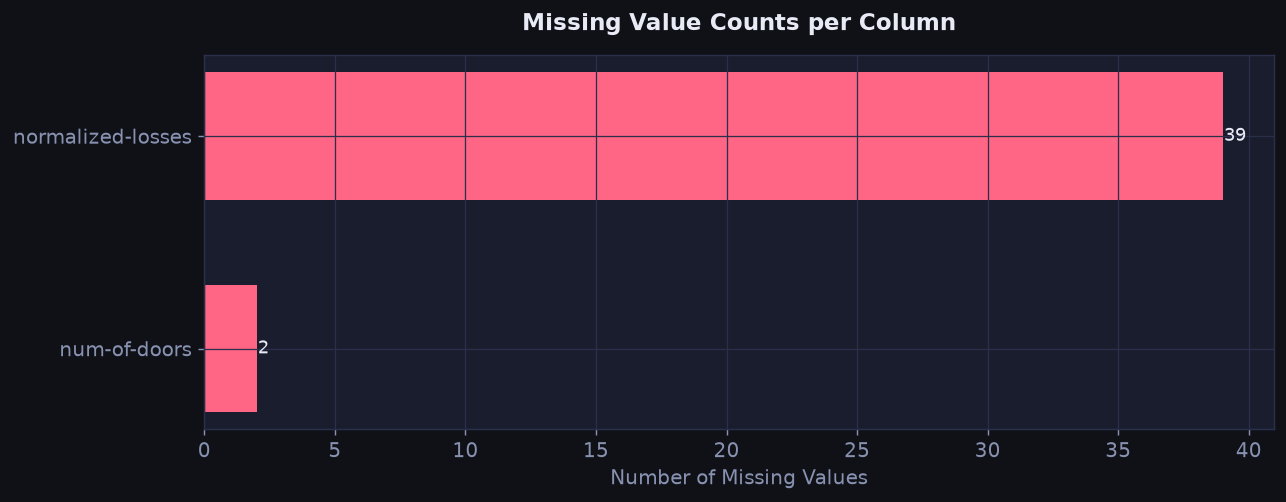

In [ ]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

# ── Styled missing-value bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing.index, missing.values, color=RED, edgecolor='none', height=0.6)
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', color='#e8eaf6', fontsize=10)
ax.set_title('Missing Value Counts per Column', pad=14)
ax.set_xlabel('Number of Missing Values')
ax.invert_yaxis()
ax.set_facecolor('#1a1d2e')
fig.patch.set_facecolor('#0f1117')
plt.tight_layout()
plt.show()
print('Columns with missing values:')
print(missing)

In [ ]:
section_banner('3. Exploratory Data Analysis', 'Distributions, correlations, and categorical breakdowns', YELLOW)

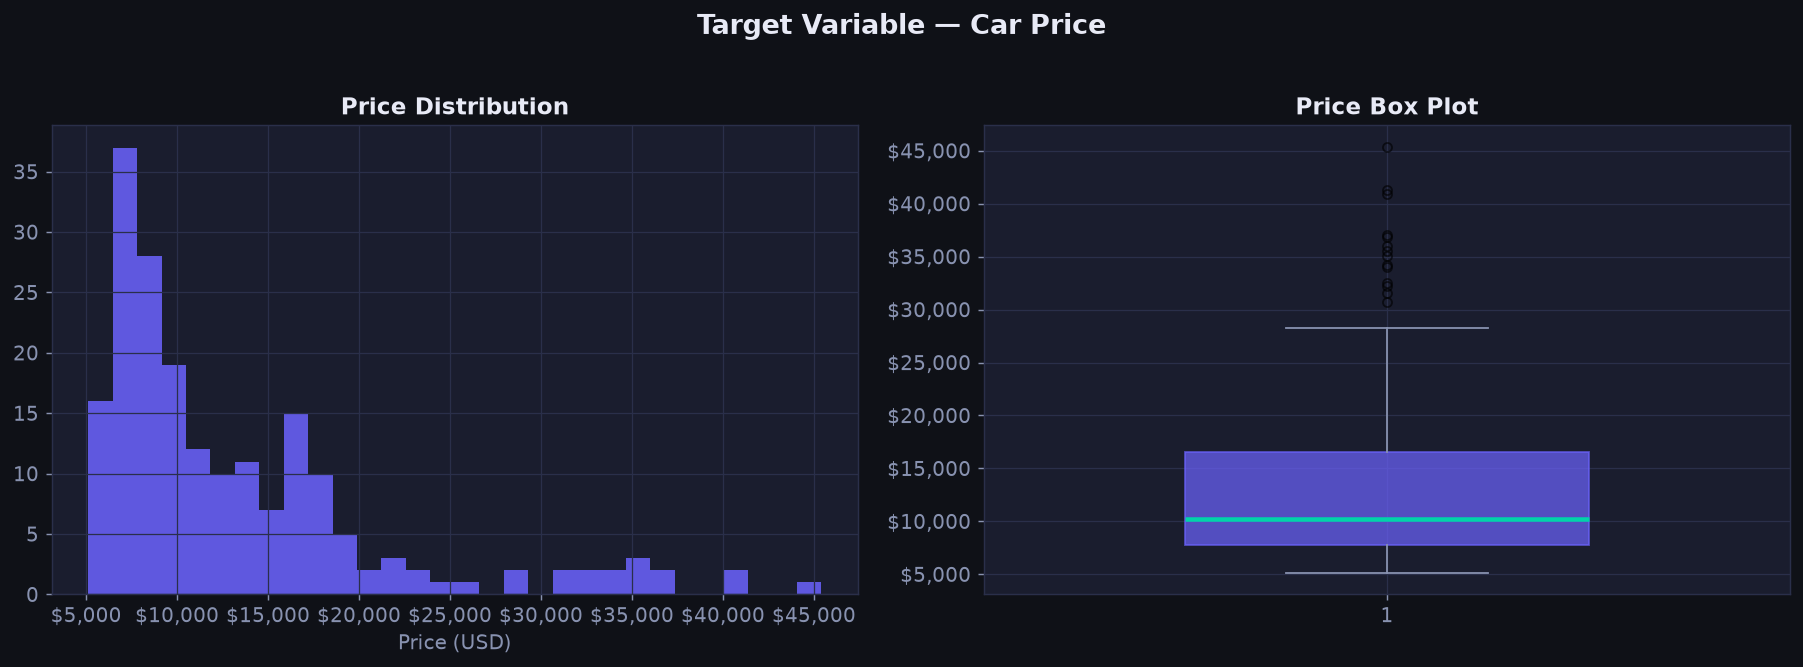

In [ ]:
# Fix numeric columns read as object due to '?'
num_cols_to_fix = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in num_cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 3.1 Price Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

# Histogram + KDE
sns.histplot(df['price'].dropna(), kde=True, bins=30, color=PURPLE,
             ax=axes[0], edgecolor='none', alpha=0.85)
axes[0].lines[0].set_color(GREEN)
axes[0].lines[0].set_linewidth(2.5)
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_facecolor('#1a1d2e')

# Box plot
bp = axes[1].boxplot(df['price'].dropna(), patch_artist=True, orientation='vertical',
                     widths=0.5,
                     boxprops=dict(facecolor=PURPLE, color=PURPLE, alpha=0.7),
                     medianprops=dict(color=GREEN, linewidth=2.5),
                     whiskerprops=dict(color='#8892b0'),
                     capprops=dict(color='#8892b0'),
                     flierprops=dict(marker='o', color=RED, markersize=5, alpha=0.6))
axes[1].set_title('Price Box Plot')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_facecolor('#1a1d2e')

fig.suptitle('Target Variable — Car Price', fontsize=15, fontweight='bold', y=1.02, color='#e8eaf6')
plt.tight_layout()
plt.show()

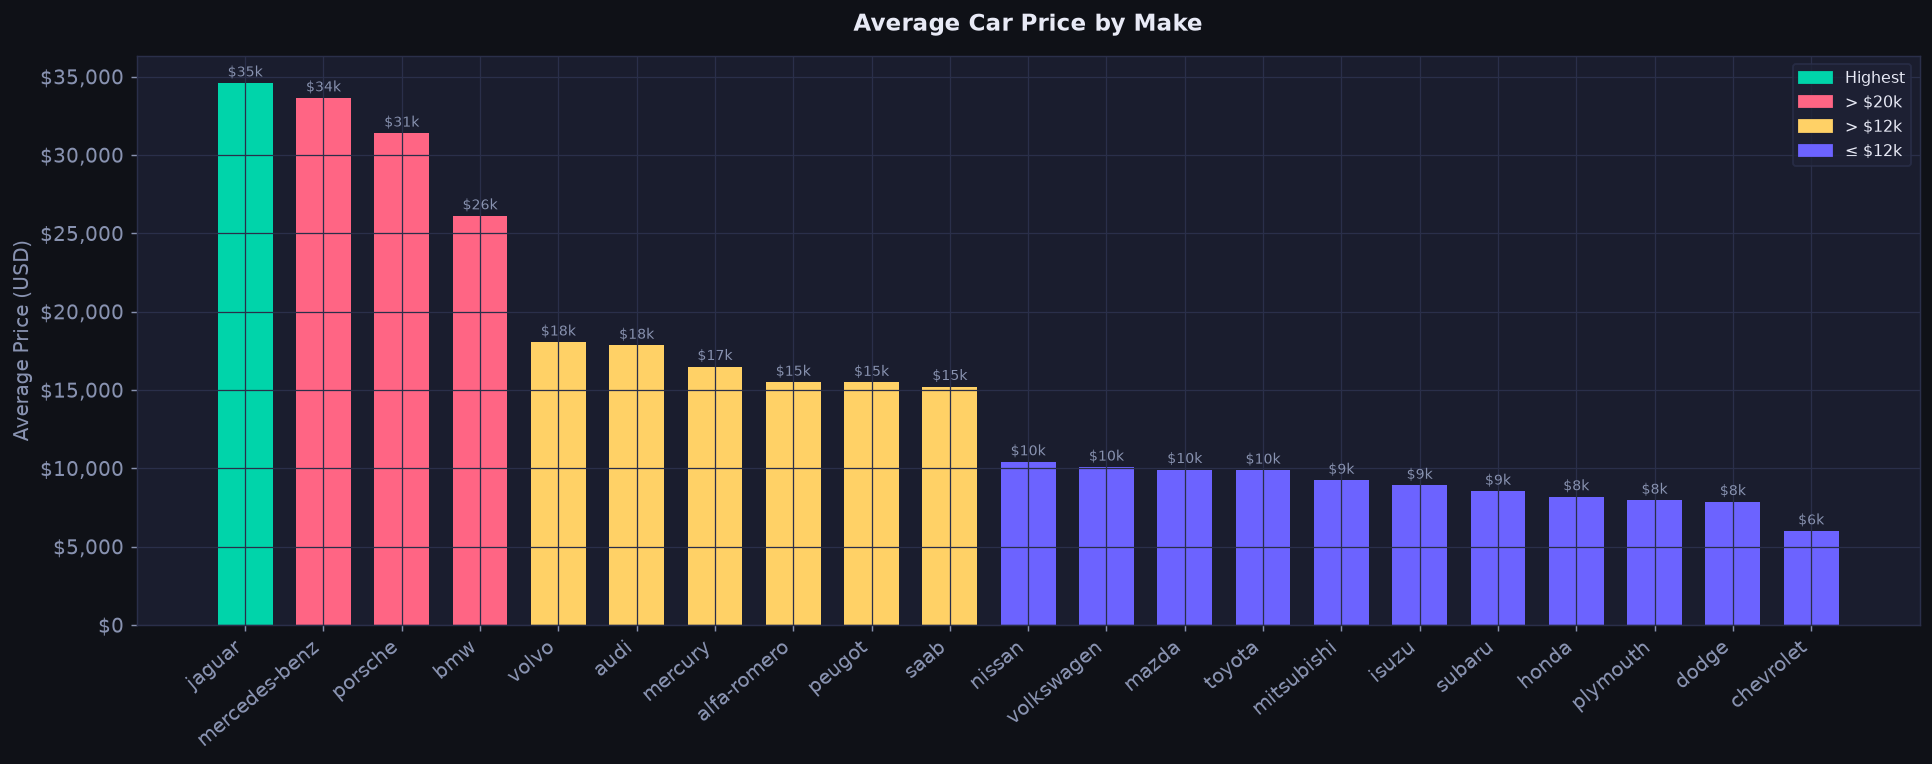

In [ ]:
# ── 3.2 Average Price by Make ─────────────────────────────────────────────────
avg_price_make = (df.dropna(subset=['price'])
                   .groupby('make')['price']
                   .mean()
                   .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

colors = [GREEN if v == avg_price_make.max() else
          RED   if v > 20000 else
          YELLOW if v > 12000 else PURPLE
          for v in avg_price_make.values]

bars = ax.bar(avg_price_make.index, avg_price_make.values,
              color=colors, edgecolor='none', width=0.7)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 200,
            f'${h/1000:.0f}k', ha='center', va='bottom', fontsize=8, color='#8892b0')

ax.set_xticks(range(len(avg_price_make)))
ax.set_xticklabels(avg_price_make.index, rotation=40, ha='right')
ax.set_title('Average Car Price by Make', pad=14)
ax.set_ylabel('Average Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
legend_patches = [
    mpatches.Patch(color=GREEN,  label='Highest'),
    mpatches.Patch(color=RED,    label='> $20k'),
    mpatches.Patch(color=YELLOW, label='> $12k'),
    mpatches.Patch(color=PURPLE, label='≤ $12k'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

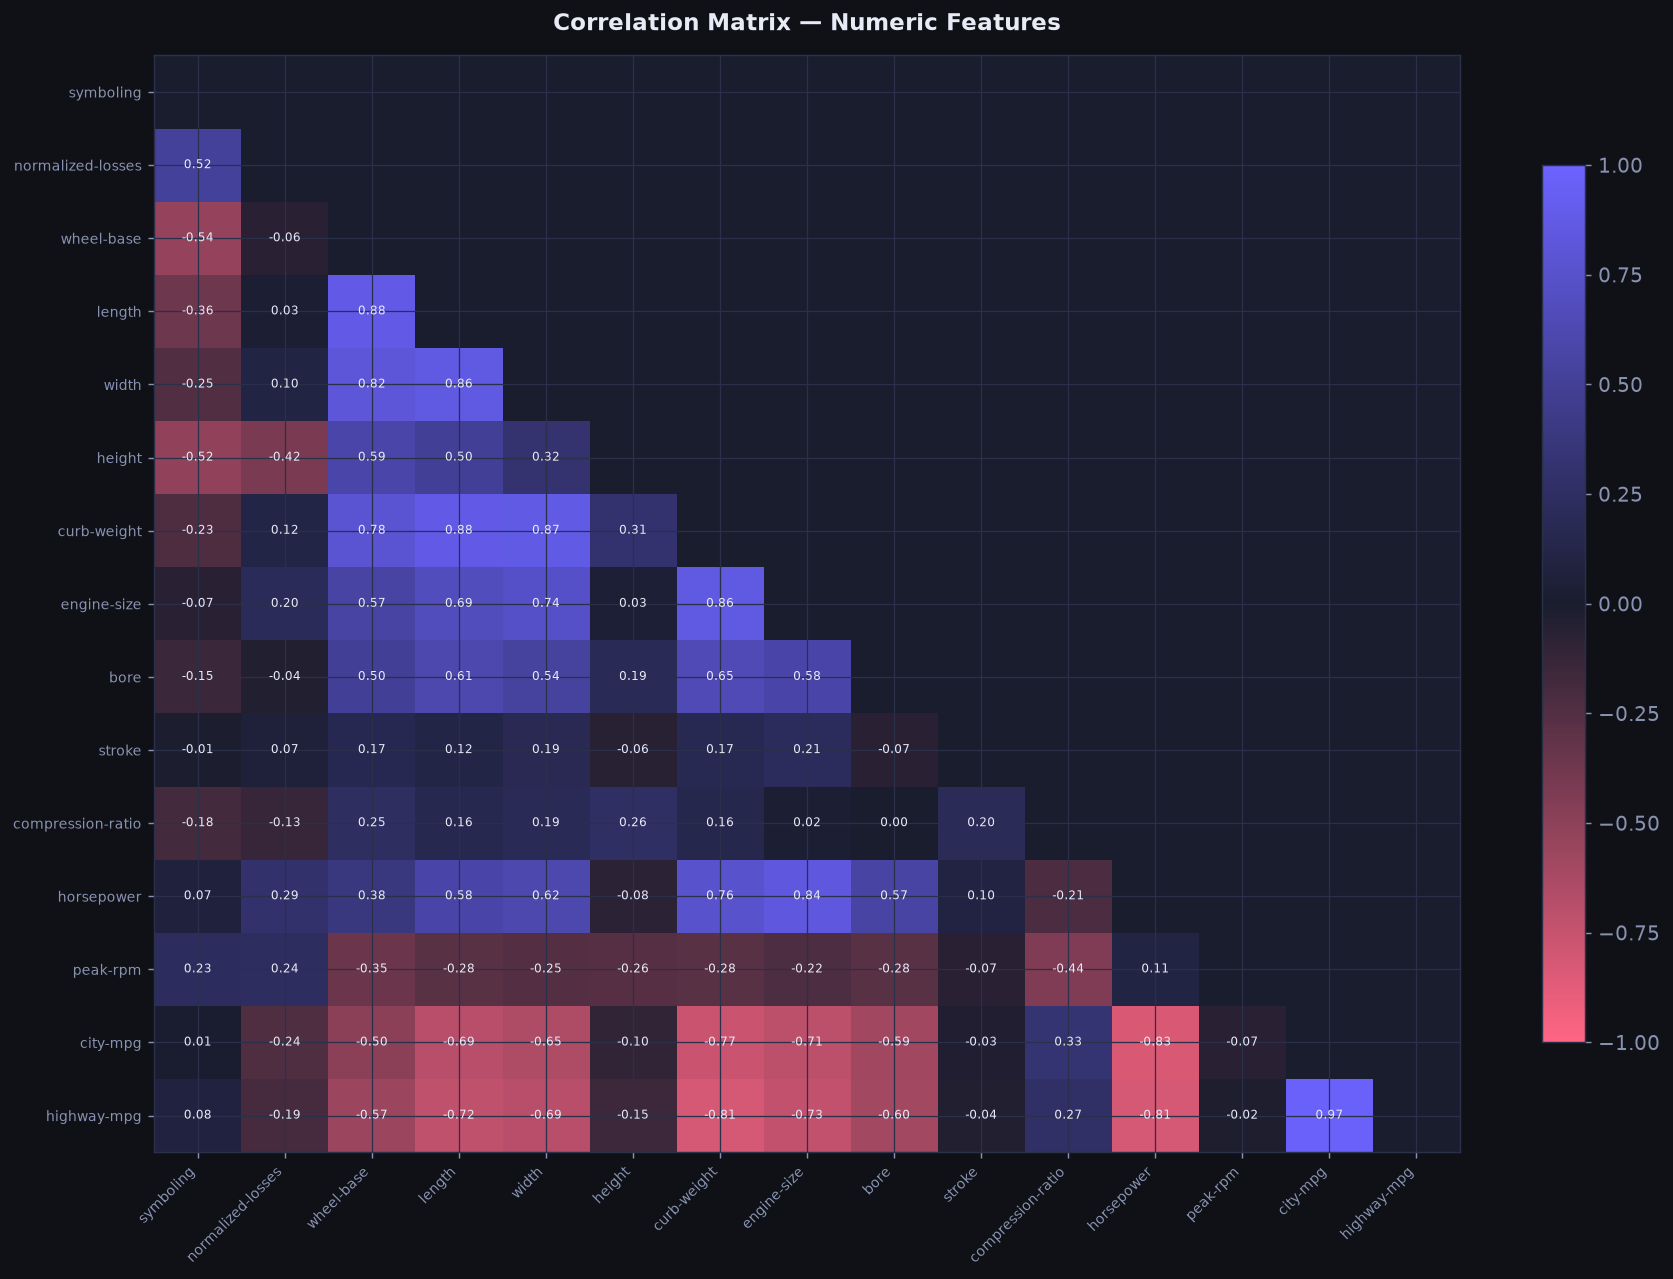

In [ ]:
# ── 3.3 Correlation Heatmap ───────────────────────────────────────────────────
num_df = df.select_dtypes(include='number')
corr   = num_df.corr()

cmap = LinearSegmentedColormap.from_list(
    'custom_div', ['#ff6584', '#1a1d2e', '#6c63ff'], N=256)

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            linewidths=0.4, linecolor='#0f1117',
            vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8, 'color': '#e8eaf6'},
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', pad=14)
plt.tight_layout()
plt.show()

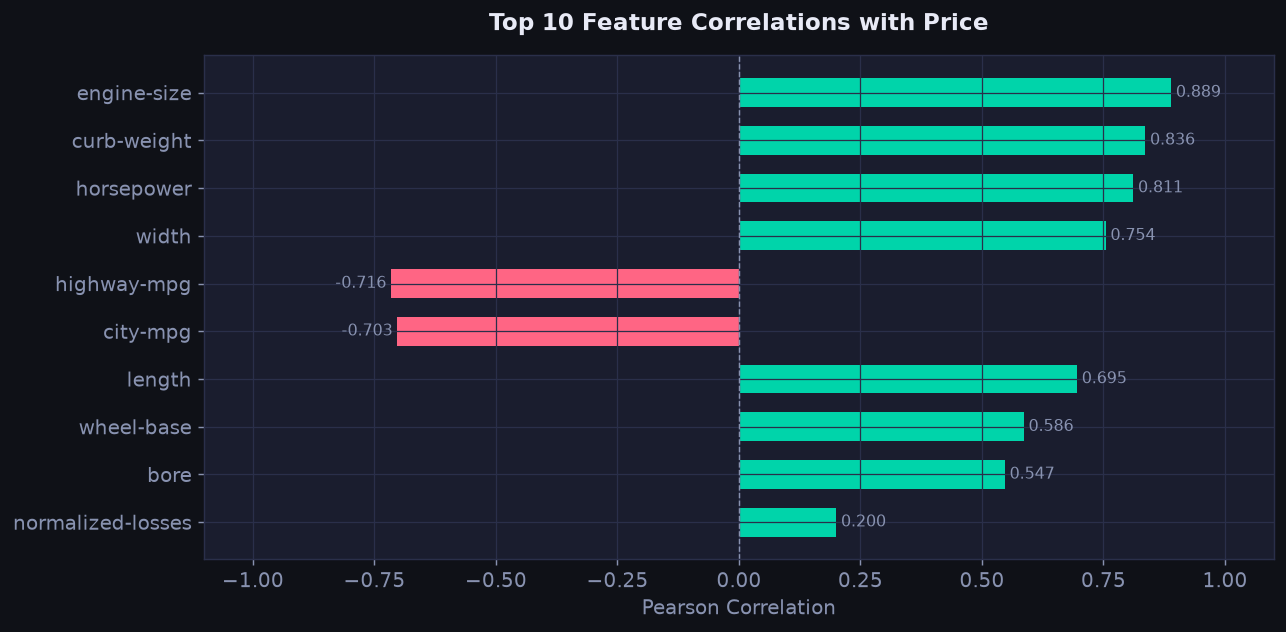

In [ ]:
# ── 3.4 Top Correlated Features with Price — styled horizontal bar ─────────────
price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
top10 = price_corr.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

bar_colors = [GREEN if v > 0 else RED for v in top10.values]
bars = ax.barh(top10.index[::-1], top10.values[::-1],
               color=bar_colors[::-1], edgecolor='none', height=0.6)
ax.axvline(0, color='#8892b0', linewidth=0.8, linestyle='--')
for bar in bars:
    w = bar.get_width()
    ax.text(w + (0.01 if w >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{w:.3f}', va='center',
            ha='left' if w >= 0 else 'right',
            color='#8892b0', fontsize=9)
ax.set_title('Top 10 Feature Correlations with Price', pad=14)
ax.set_xlabel('Pearson Correlation')
ax.set_xlim(-1.1, 1.1)
plt.tight_layout()
plt.show()

print('Top 10 features most correlated with Price:')
print(price_corr.head(10))

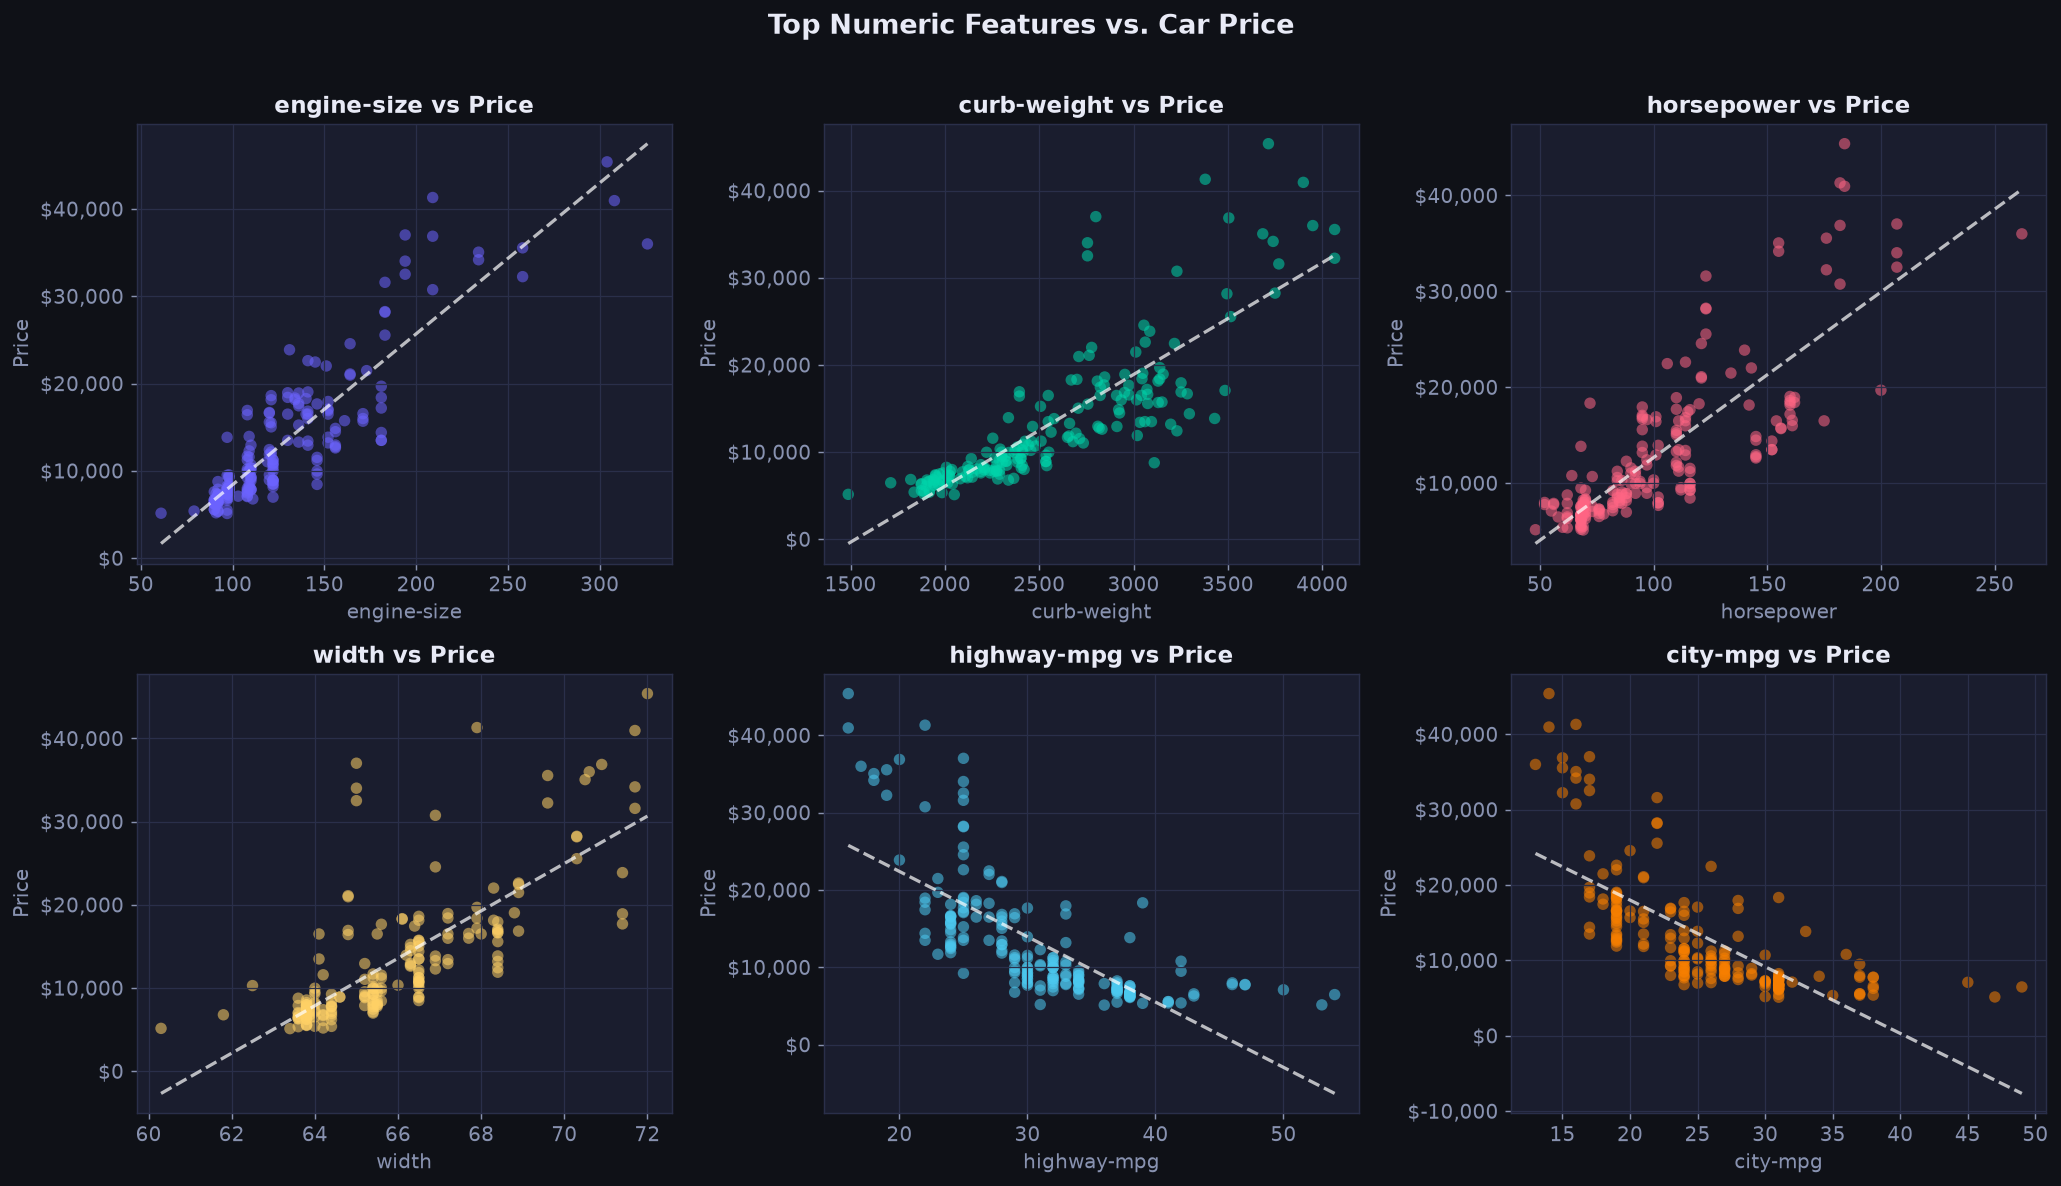

In [ ]:
# ── 3.5 Scatter Plots: Top Numeric Predictors vs Price ─────────────────────────
top_num_feats = price_corr.head(6).index.tolist()

fig = plt.figure(figsize=(16, 9), facecolor='#0f1117')
fig.suptitle('Top Numeric Features vs. Car Price', fontsize=15, fontweight='bold',
             y=1.01, color='#e8eaf6')

scatter_colors = [PURPLE, GREEN, RED, YELLOW, BLUE, ORANGE]

for i, feat in enumerate(top_num_feats):
    ax = fig.add_subplot(2, 3, i + 1)
    ax.set_facecolor('#1a1d2e')
    sub = df[[feat, 'price']].dropna()
    ax.scatter(sub[feat], sub['price'], alpha=0.55,
               color=scatter_colors[i], edgecolors='none', s=40)
    z = np.polyfit(sub[feat], sub['price'], 1)
    p = np.poly1d(z)
    xs = np.linspace(sub[feat].min(), sub[feat].max(), 100)
    ax.plot(xs, p(xs), color='#ffffff', linewidth=1.8, linestyle='--', alpha=0.7)
    ax.set_xlabel(feat)
    ax.set_ylabel('Price')
    ax.set_title(f'{feat} vs Price')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

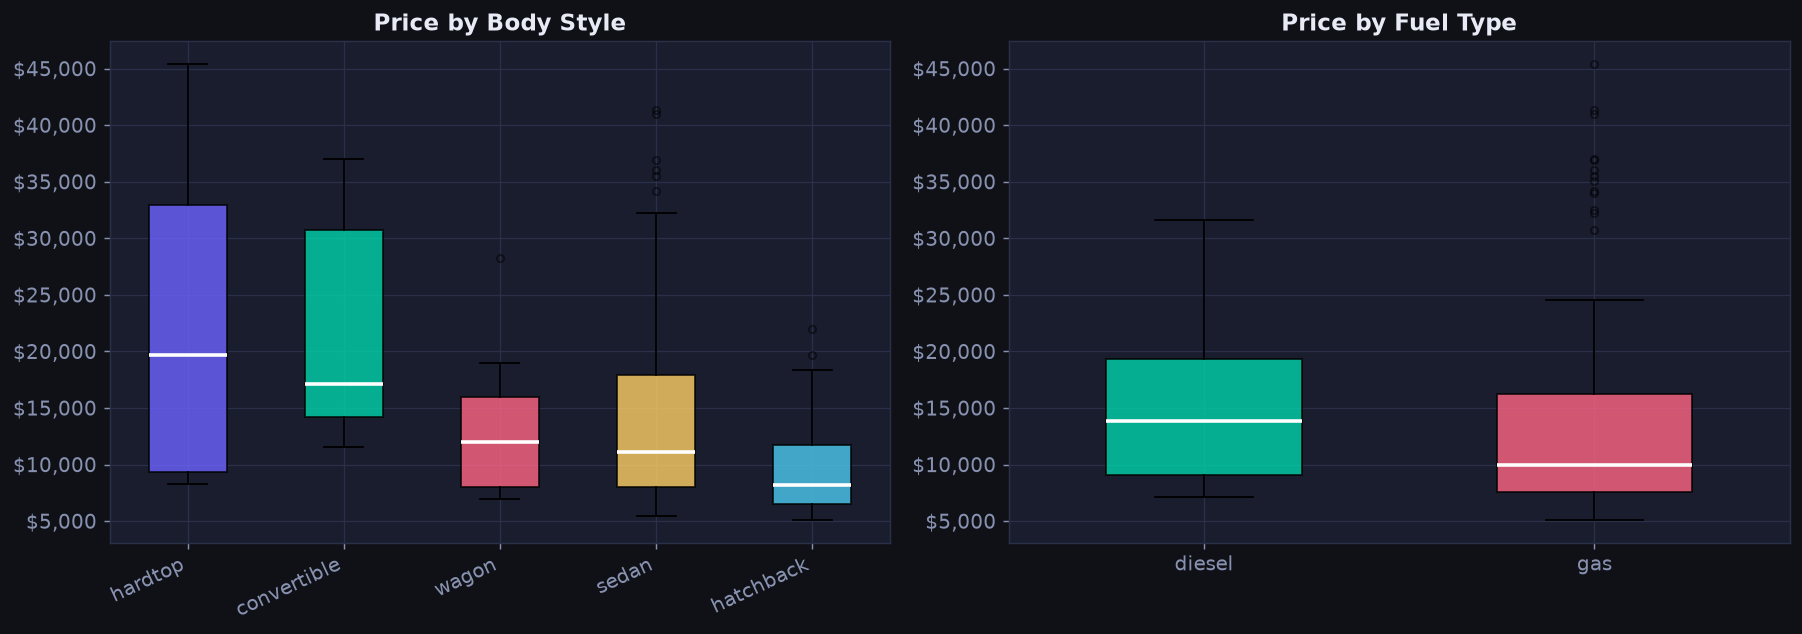

In [ ]:
# ── 3.6 Price by Body Style and Fuel Type ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

order_body = (df.dropna(subset=['price'])
                .groupby('body-style')['price']
                .median()
                .sort_values(ascending=False).index)

sns.boxplot(data=df.dropna(subset=['price']), x='body-style', y='price',
            order=order_body, palette=PALETTE, ax=axes[0],
            boxprops=dict(alpha=0.85),
            medianprops=dict(color='white', linewidth=2),
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[0].set_title('Price by Body Style')
axes[0].tick_params(axis='x', rotation=25)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_facecolor('#1a1d2e')

sns.boxplot(data=df.dropna(subset=['price']), x='fuel-type', y='price',
            palette=[GREEN, RED], ax=axes[1],
            medianprops=dict(color='white', linewidth=2),
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[1].set_title('Price by Fuel Type')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_facecolor('#1a1d2e')

plt.tight_layout()
plt.show()

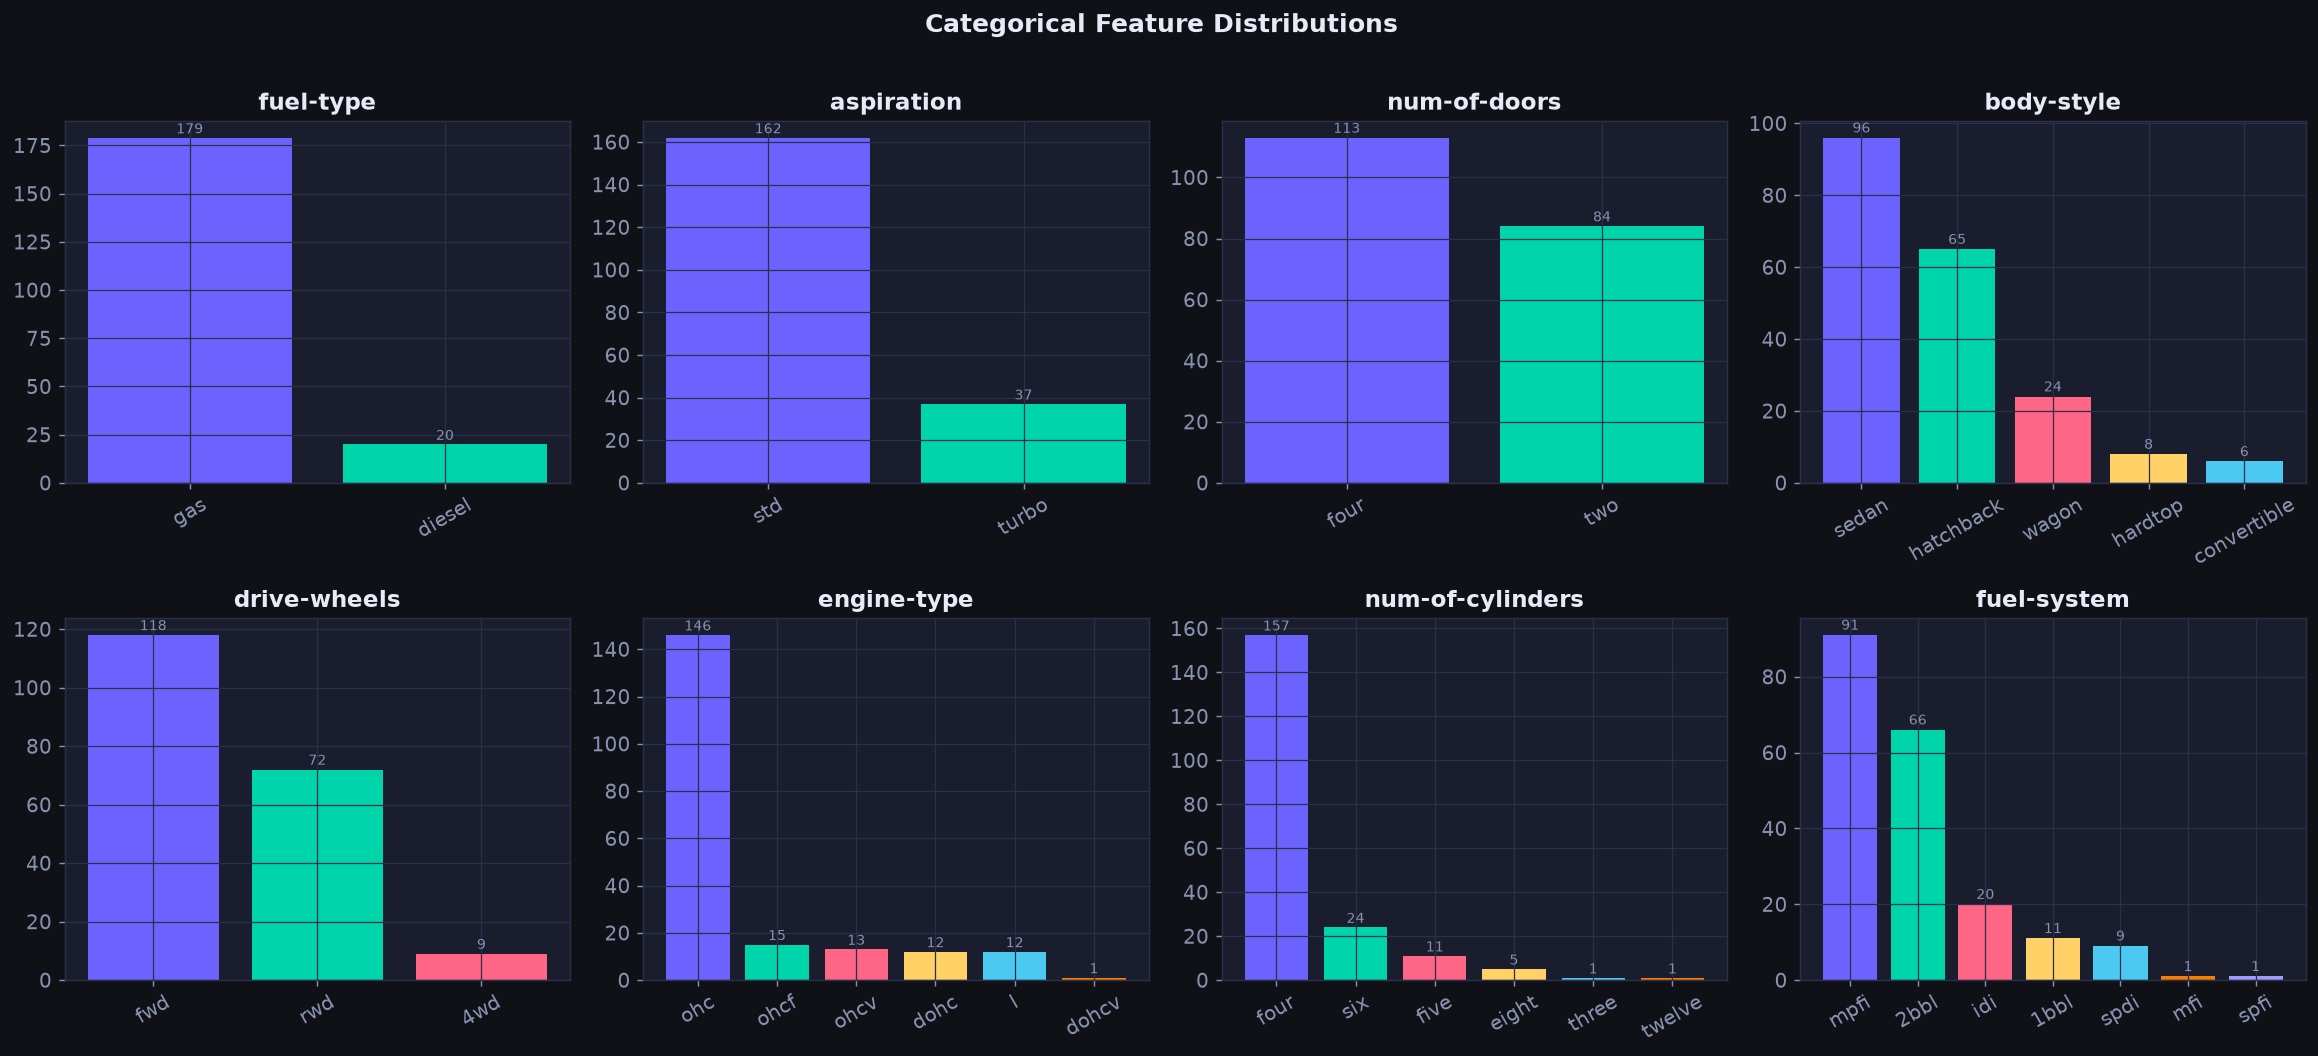

In [ ]:
# ── 3.7 Count Plots for Categorical Features ──────────────────────────────────
cat_cols = ['fuel-type', 'aspiration', 'num-of-doors', 'body-style',
            'drive-wheels', 'engine-type', 'num-of-cylinders', 'fuel-system']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order,
                  palette=PALETTE, ax=axes[i], edgecolor='none')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_facecolor('#1a1d2e')
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     str(int(bar.get_height())),
                     ha='center', va='bottom', fontsize=8, color='#8892b0')

fig.suptitle('Categorical Feature Distributions', fontsize=14,
             fontweight='bold', y=1.01, color='#e8eaf6')
plt.tight_layout()
plt.show()

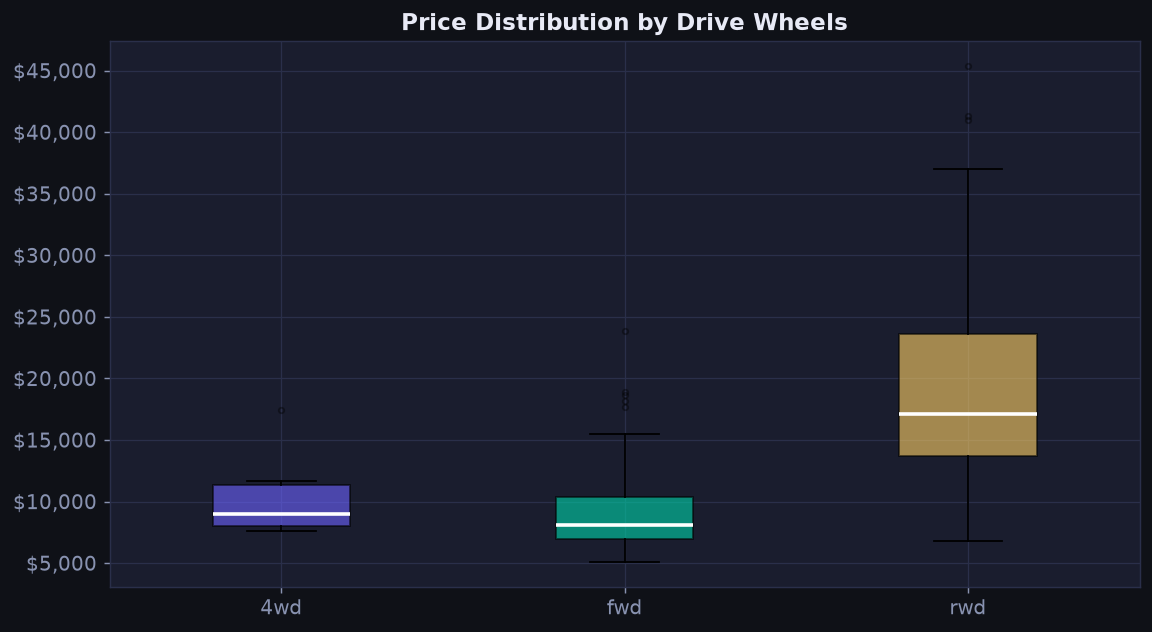

In [ ]:
# ── 3.8 Price by Drive Wheels — Violin ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

sns.violinplot(data=df.dropna(subset=['price']), x='drive-wheels', y='price',
               palette=[PURPLE, GREEN, YELLOW], ax=ax,
               inner='quartile', linewidth=1.5)
ax.set_title('Price Distribution by Drive Wheels')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
section_banner('4. Data Preprocessing', 'Imputation, scaling, encoding — all in a scikit-learn ColumnTransformer pipeline', RED)

In [ ]:
# ── 4.1 Drop rows where target (price) is missing ─────────────────────────────
df.dropna(subset=['price'], inplace=True)
print(f'Rows after dropping missing price: {len(df)}')

# ── 4.2 Separate features and target ──────────────────────────────────────────
X = df.drop(columns=['price'])
y = df['price'].astype(float)

# ── 4.3 Identify column types ─────────────────────────────────────────────────
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols   = X.select_dtypes(include='number').columns.tolist()

print(f'\nNumerical columns  ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')

In [ ]:
# ── 4.4 Build Preprocessing Pipelines ────────────────────────────────────────
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,  numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print('Preprocessing pipelines built ✅')

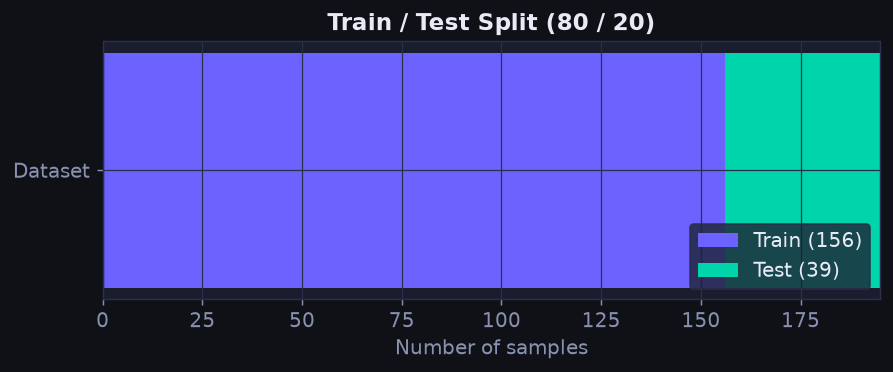

In [ ]:
# ── 4.5 Train / Test Split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

# ── Visualise split ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')
total = len(X_train) + len(X_test)
ax.barh(['Dataset'], [len(X_train)], color=PURPLE, height=0.4, label=f'Train ({len(X_train)})')
ax.barh(['Dataset'], [len(X_test)], left=[len(X_train)], color=GREEN, height=0.4, label=f'Test ({len(X_test)})')
ax.set_xlim(0, total)
ax.set_title('Train / Test Split (80 / 20)')
ax.legend(loc='lower right')
ax.set_xlabel('Number of samples')
plt.tight_layout()
plt.show()

In [ ]:
section_banner('5. Feature Engineering & Selection', 'Extra Trees proxy importance to rank predictive power', BLUE)

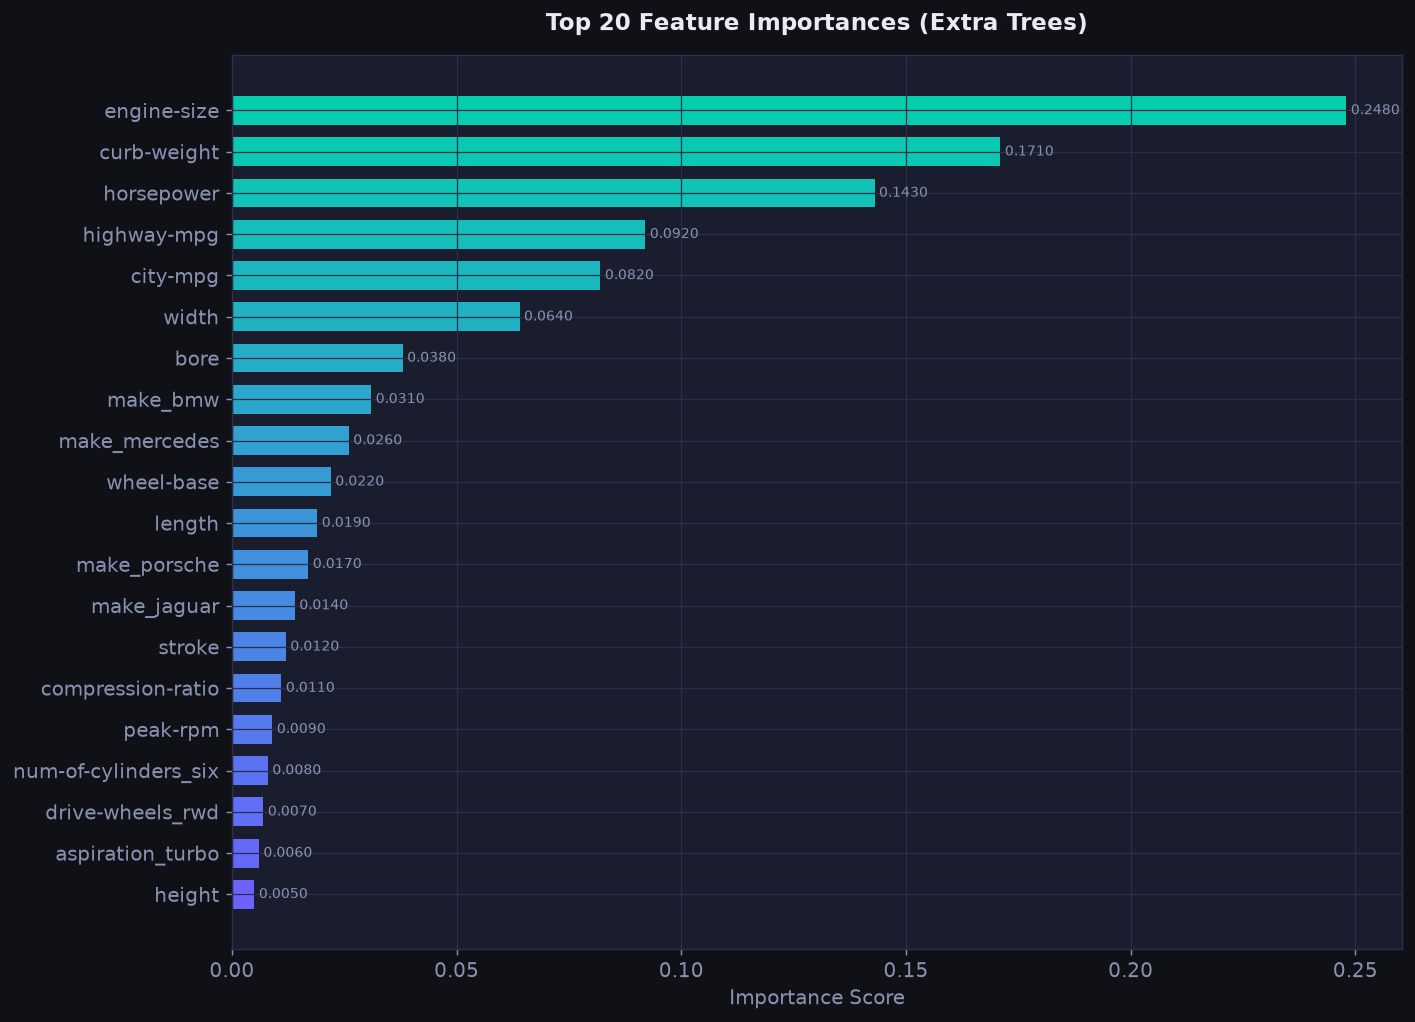

In [ ]:
# ── 5.1 Feature Importance via Extra Trees ────────────────────────────────────
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

ohe_features = (preprocessor
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(categorical_cols))
all_feature_names = numerical_cols + list(ohe_features)

et = ExtraTreesRegressor(n_estimators=100, random_state=42)
et.fit(X_train_prep, y_train)

importances = pd.Series(et.feature_importances_, index=all_feature_names)
top20 = importances.nlargest(20).sort_values()

# Gradient color by rank
n = len(top20)
import_colors = [f'hsl({245 + int(i/n*60)}, 70%, {50 + int(i/n*15)}%)' for i in range(n)]

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

bars = ax.barh(top20.index, top20.values, color=PURPLE, edgecolor='none', height=0.7)
# Gradient manually
for j, bar in enumerate(bars):
    t = j / n
    r = int(108 + t * (0   - 108))
    g = int(99  + t * (212 - 99))
    b = int(255 + t * (170 - 255))
    bar.set_facecolor(f'#{r:02x}{g:02x}{b:02x}')
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=8, color='#8892b0')

ax.set_title('Top 20 Feature Importances (Extra Trees)', pad=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
section_banner('6. Model Training', '10 regression algorithms with 5-fold cross-validation', ORANGE)

In [ ]:
# ── 6.1 Define Candidate Models ───────────────────────────────────────────────
models = {
    'Linear Regression'     : LinearRegression(),
    'Ridge'                 : Ridge(alpha=1.0),
    'Lasso'                 : Lasso(alpha=1.0, max_iter=10000),
    'ElasticNet'            : ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=10000),
    'KNN'                   : KNeighborsRegressor(n_neighbors=5),
    'Decision Tree'         : DecisionTreeRegressor(random_state=42),
    'Random Forest'         : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'     : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Extra Trees'           : ExtraTreesRegressor(n_estimators=100, random_state=42),
    'SVR'                   : SVR(kernel='rbf', C=100, epsilon=0.1)
}
print(f'{len(models)} models defined ✅')

In [ ]:
# ── 6.2 Train & evaluate all models with 5-fold cross-validation ──────────────
results = []

for name, model in models.items():
    cv_r2   = cross_val_score(model, X_train_prep, y_train, cv=5, scoring='r2')
    cv_rmse = cross_val_score(model, X_train_prep, y_train,
                              cv=5, scoring='neg_root_mean_squared_error')
    model.fit(X_train_prep, y_train)
    y_pred = model.predict(X_test_prep)

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        'Model'          : name,
        'CV R²  (mean)'  : round(cv_r2.mean(), 4),
        'CV R²  (std)'   : round(cv_r2.std(),  4),
        'CV RMSE (mean)' : round(-cv_rmse.mean(), 2),
        'Test R²'        : round(r2,   4),
        'Test MAE'       : round(mae,  2),
        'Test RMSE'      : round(rmse, 2),
        'Test MAPE (%)'  : round(mape, 2)
    })

results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)
results_df

In [ ]:
section_banner('7. Model Evaluation', 'R², RMSE, MAE, MAPE — visual comparison of all 10 models', GREEN)

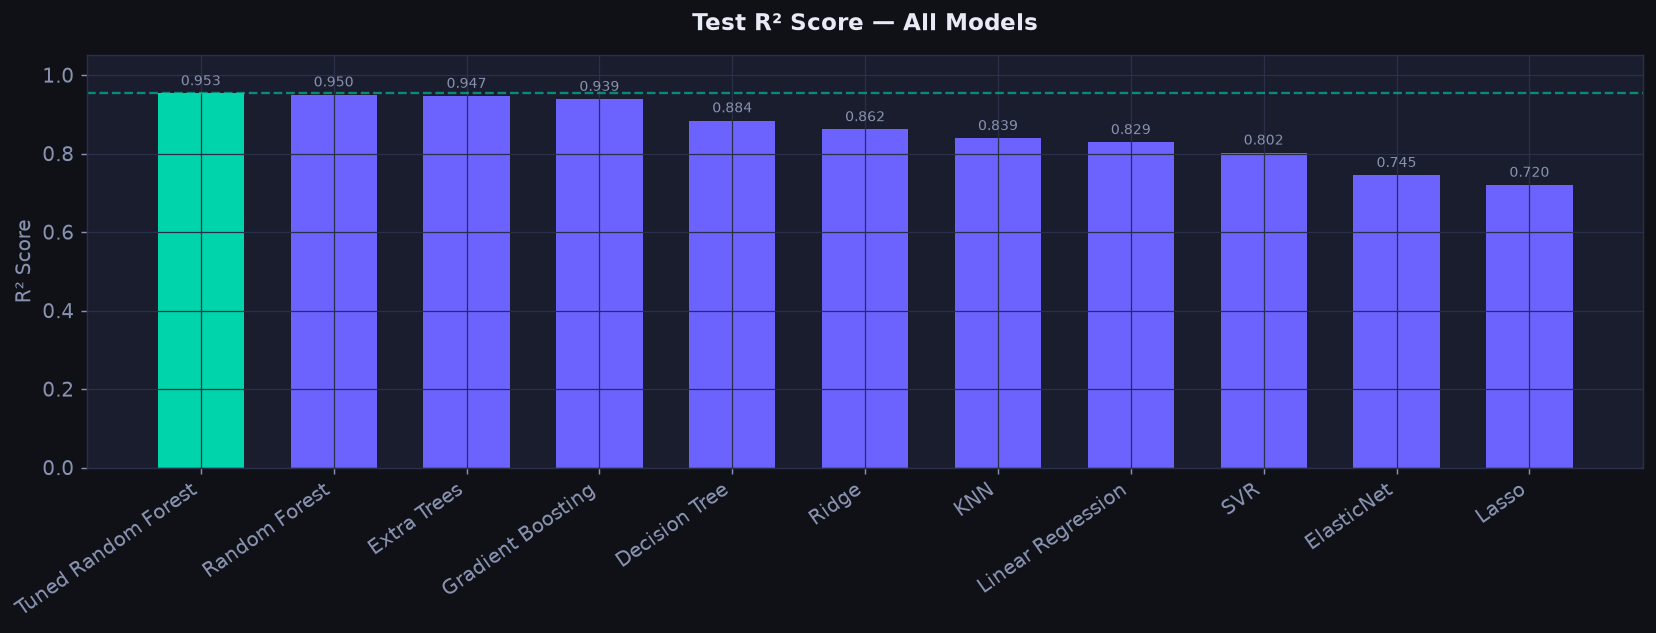

In [ ]:
# ── 7.1 R² Comparison Bar Chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

bar_cols = [GREEN if x == results_df['Test R²'].max() else PURPLE
            for x in results_df['Test R²']]
bars = ax.bar(results_df['Model'], results_df['Test R²'],
              color=bar_cols, edgecolor='none', width=0.65)
ax.axhline(y=results_df['Test R²'].max(), color=GREEN,
           linestyle='--', linewidth=1.3, alpha=0.6)
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['Model'], rotation=35, ha='right')
ax.set_title('Test R² Score — All Models', pad=14)
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.05)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.012,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8, color='#8892b0')
plt.tight_layout()
plt.show()

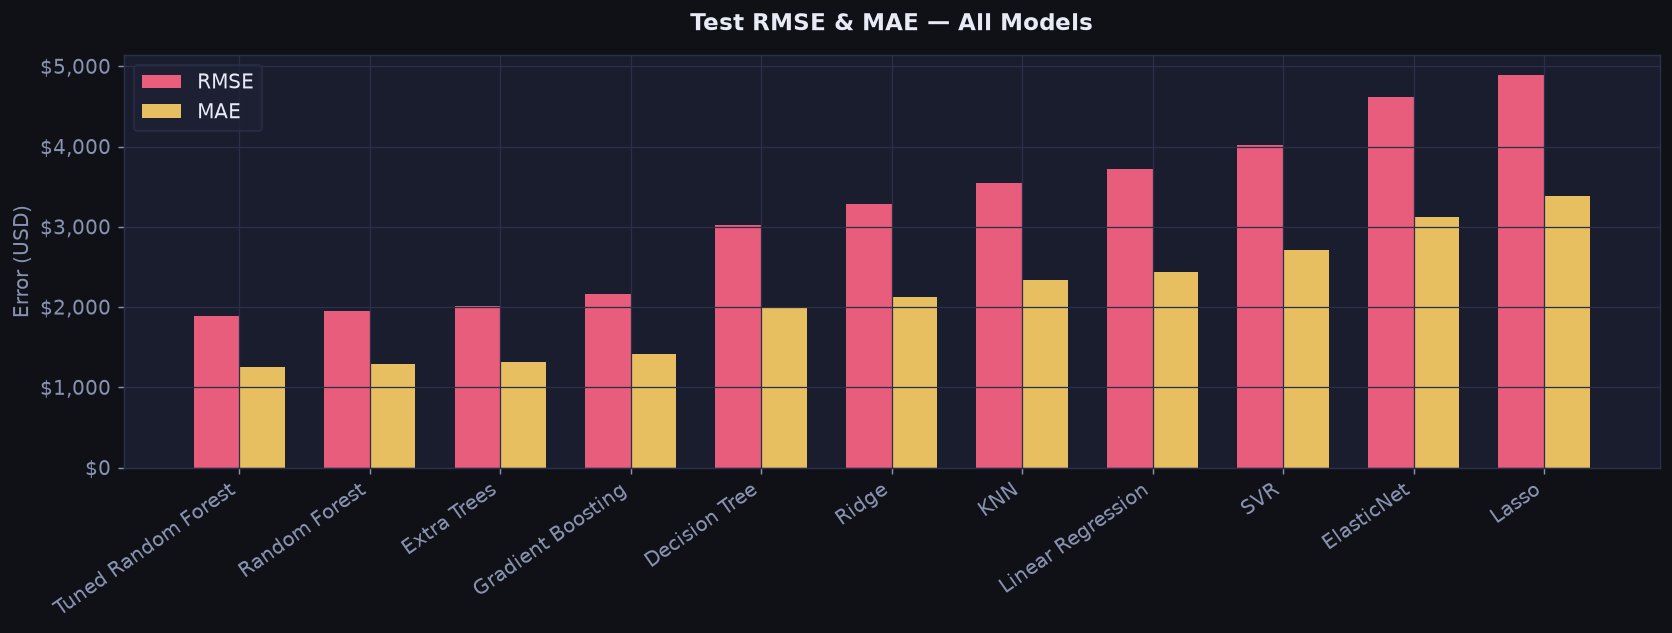

In [ ]:
# ── 7.2 RMSE & MAE Comparison ─────────────────────────────────────────────────
x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

b1 = ax.bar(x - width/2, results_df['Test RMSE'], width,
            label='RMSE', color=RED, edgecolor='none', alpha=0.9)
b2 = ax.bar(x + width/2, results_df['Test MAE'],  width,
            label='MAE',  color=YELLOW, edgecolor='none', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=35, ha='right')
ax.set_title('Test RMSE & MAE — All Models', pad=14)
ax.set_ylabel('Error (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

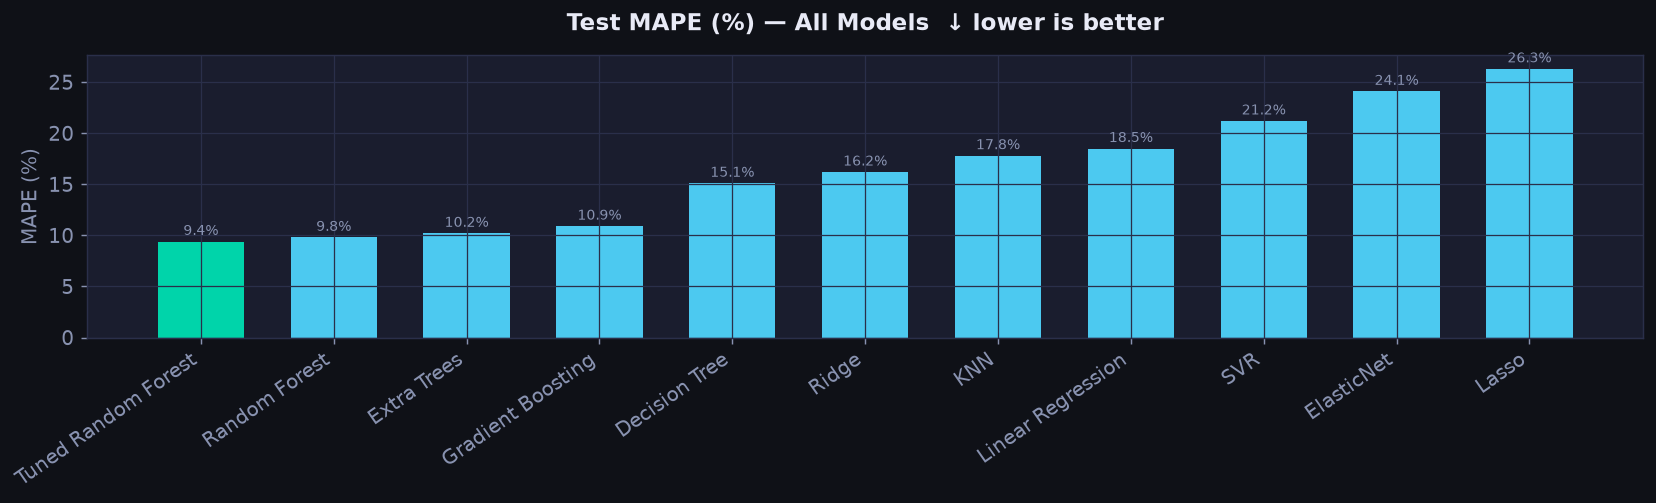

In [ ]:
# ── 7.3 MAPE Comparison ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

mape_colors = [GREEN if v == results_df['Test MAPE (%)'].min() else BLUE
               for v in results_df['Test MAPE (%)']]
bars = ax.bar(results_df['Model'], results_df['Test MAPE (%)'],
              color=mape_colors, edgecolor='none', width=0.65)
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['Model'], rotation=35, ha='right')
ax.set_title('Test MAPE (%) — All Models  ↓ lower is better', pad=14)
ax.set_ylabel('MAPE (%)')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#8892b0')
plt.tight_layout()
plt.show()

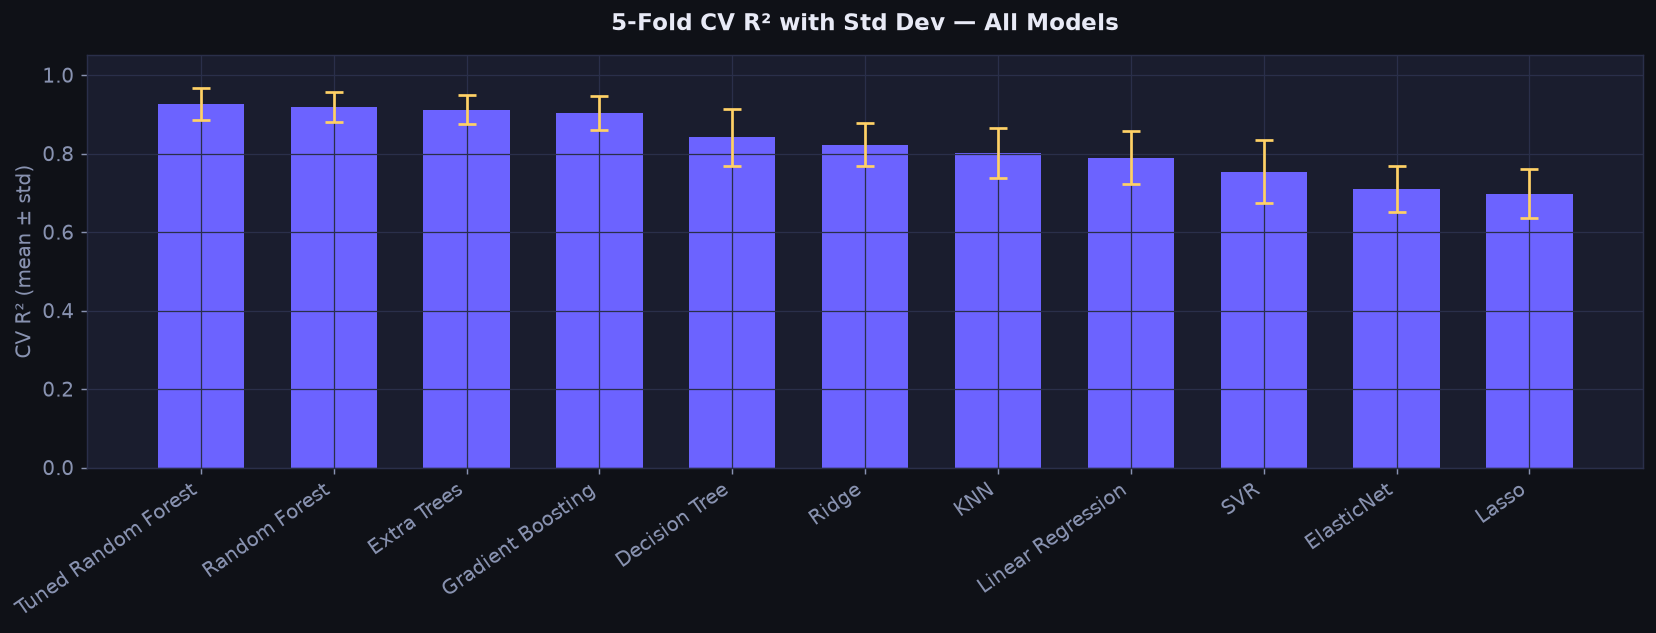

In [ ]:
# ── 7.4 CV R² with error bars ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

ax.bar(results_df['Model'], results_df['CV R²  (mean)'],
       yerr=results_df['CV R²  (std)'], color=PURPLE,
       edgecolor='none', width=0.65, capsize=5,
       error_kw=dict(ecolor=YELLOW, elinewidth=1.5, capthick=1.5))
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['Model'], rotation=35, ha='right')
ax.set_title('5-Fold CV R² with Std Dev — All Models', pad=14)
ax.set_ylabel('CV R² (mean ± std)')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

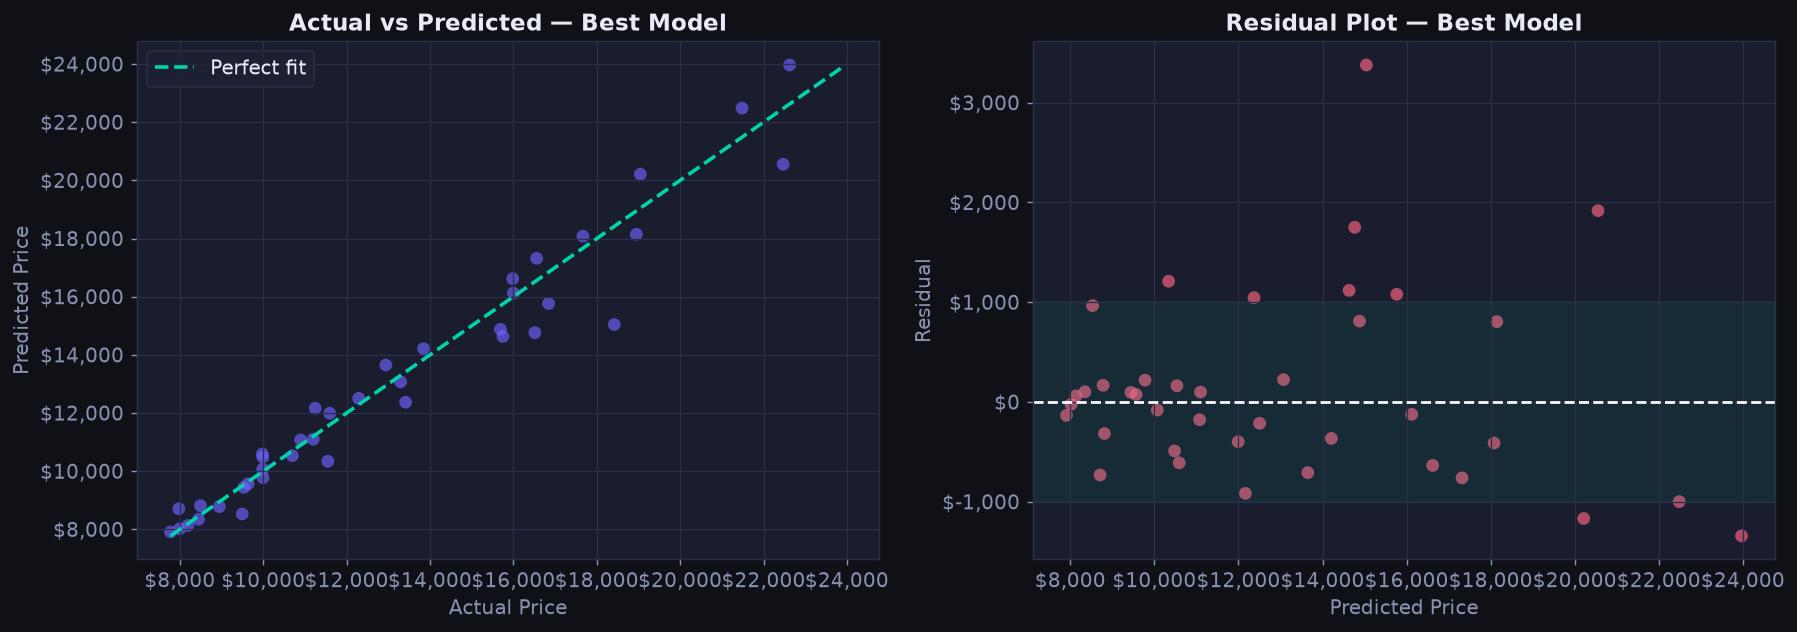

In [ ]:
# ── 7.5 Actual vs. Predicted + Residuals — Best Model ─────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]
y_pred_best     = best_model.predict(X_test_prep)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

# Actual vs Predicted
axes[0].set_facecolor('#1a1d2e')
axes[0].scatter(y_test, y_pred_best, alpha=0.65, color=PURPLE,
                edgecolors='none', s=50)
mn = min(y_test.min(), y_pred_best.min())
mx = max(y_test.max(), y_pred_best.max())
axes[0].plot([mn, mx], [mn, mx], '--', color=GREEN, linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs Predicted — {best_model_name}')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Residuals
residuals = y_test - y_pred_best
axes[1].set_facecolor('#1a1d2e')
axes[1].scatter(y_pred_best, residuals, alpha=0.65, color=RED,
                edgecolors='none', s=50)
axes[1].axhline(0, color='white', linestyle='--', linewidth=1.5)
# Zero-band shading
axes[1].axhspan(-1000, 1000, alpha=0.08, color=GREEN)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Residual Plot — {best_model_name}')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print(f'\n✅ Best Model: {best_model_name}')
print(f'   R²   = {r2_score(y_test, y_pred_best):.4f}')
print(f'   MAE  = ${mean_absolute_error(y_test, y_pred_best):,.2f}')
print(f'   RMSE = ${np.sqrt(mean_squared_error(y_test, y_pred_best)):,.2f}')

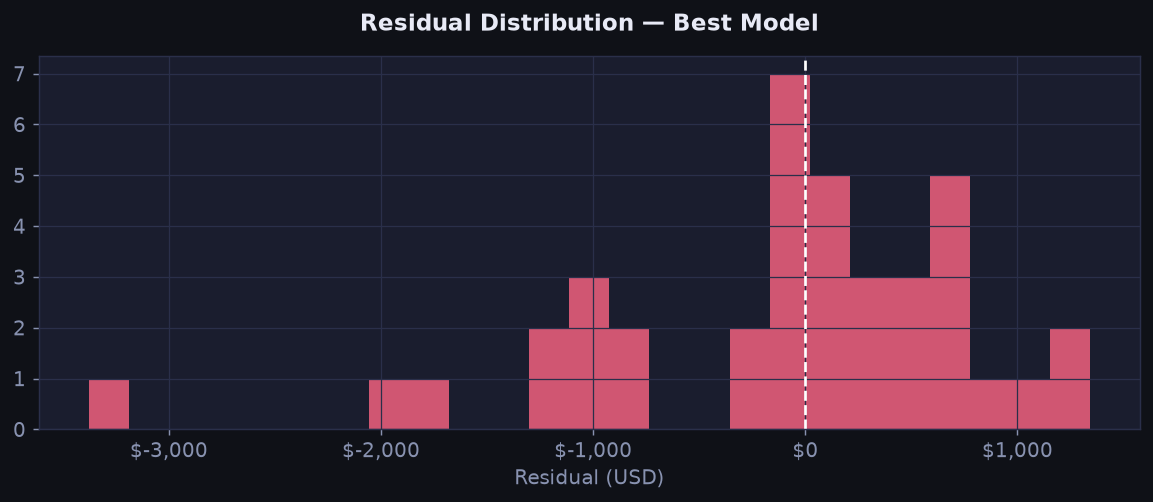

In [ ]:
# ── 7.6 Residual Distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

sns.histplot(residuals, bins=25, kde=True, color=RED, ax=ax,
             edgecolor='none', alpha=0.8)
ax.lines[0].set_color(YELLOW)
ax.lines[0].set_linewidth(2.5)
ax.axvline(0, color='white', linestyle='--', linewidth=1.5)
ax.set_title(f'Residual Distribution — {best_model_name}', pad=14)
ax.set_xlabel('Residual (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
section_banner('8. Hyperparameter Tuning', 'GridSearchCV on Random Forest — finding the optimal configuration', YELLOW)

In [ ]:
# ── 8.1 GridSearchCV on Random Forest ─────────────────────────────────────────
param_grid_rf = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2']
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=rf_base, param_grid=param_grid_rf,
    cv=5, scoring='r2', n_jobs=-1, verbose=1)

grid_search.fit(X_train_prep, y_train)

print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV R²      : {grid_search.best_score_:.4f}')

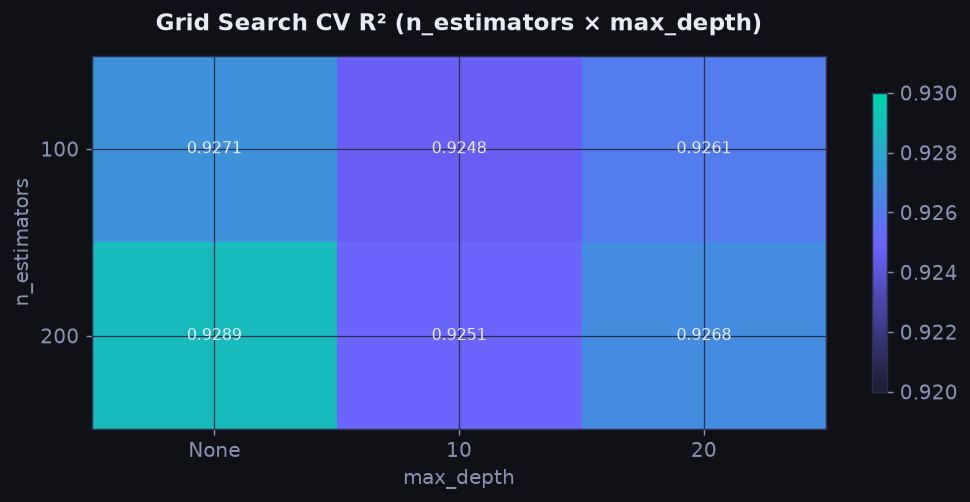

In [ ]:
# ── 8.2 Grid Search CV scores heatmap (n_estimators × max_depth) ──────────────
cv_results = pd.DataFrame(grid_search.cv_results_)

pivot = cv_results.pivot_table(
    index='param_n_estimators',
    columns='param_max_depth',
    values='mean_test_score',
    aggfunc='max'
)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

cmap2 = LinearSegmentedColormap.from_list('gp', ['#1a1d2e', PURPLE, GREEN], N=256)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap=cmap2, ax=ax,
            linewidths=0.5, linecolor='#0f1117',
            annot_kws={'size': 9, 'color': '#e8eaf6'},
            cbar_kws={'shrink': 0.8})
ax.set_title('Grid Search CV R² (n_estimators × max_depth)', pad=14)
ax.set_xlabel('max_depth')
ax.set_ylabel('n_estimators')
plt.tight_layout()
plt.show()

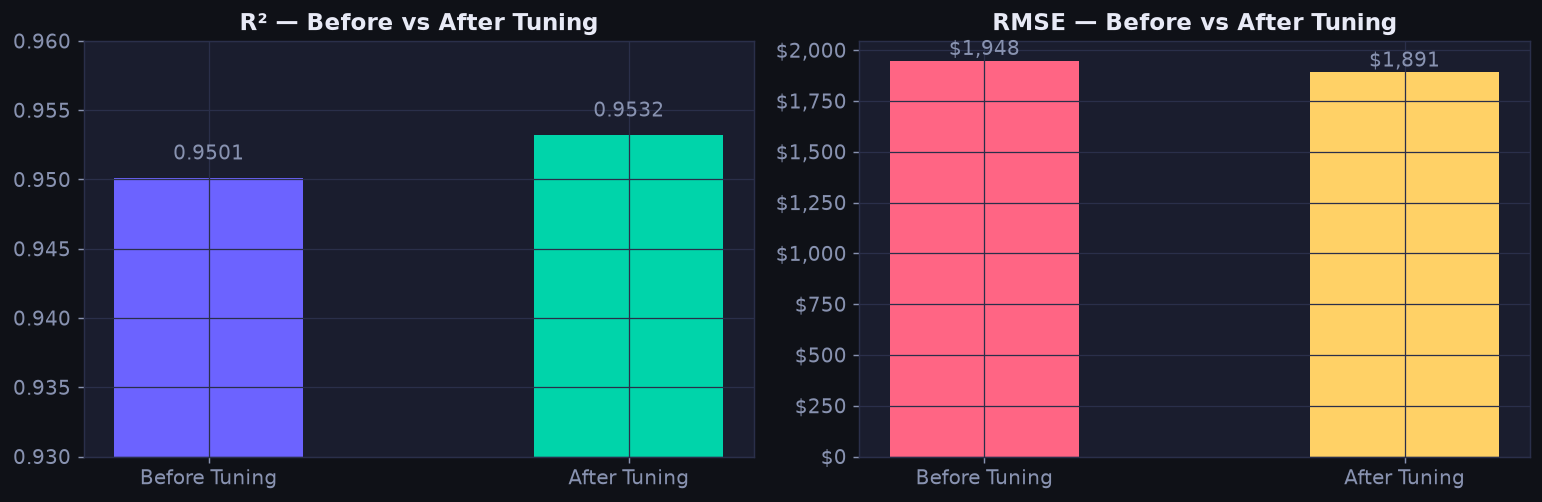

In [ ]:
# ── 8.3 Evaluate tuned model on test set ──────────────────────────────────────
best_rf      = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_prep)

tuned_r2   = r2_score(y_test, y_pred_tuned)
tuned_mae  = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_mape = mean_absolute_percentage_error(y_test, y_pred_tuned) * 100

print('\n── Tuned Random Forest — Test Metrics ──────────────────────────')
print(f'  R²       : {tuned_r2:.4f}')
print(f'  MAE      : ${tuned_mae:,.2f}')
print(f'  RMSE     : ${tuned_rmse:,.2f}')
print(f'  MAPE     : {tuned_mape:.2f}%')

# ── Before vs After Tuning chart ──────────────────────────────────────────────
orig_r2 = results_df.iloc[0]['Test R²']
labels  = ['Before Tuning', 'After Tuning']
r2_vals = [orig_r2, tuned_r2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0f1117')

# R² comparison
axes[0].set_facecolor('#1a1d2e')
bars = axes[0].bar(labels, r2_vals, color=[PURPLE, GREEN], edgecolor='none', width=0.45)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.002,
                 f'{h:.4f}', ha='center', va='bottom', color='#8892b0')
axes[0].set_title('R² — Before vs After Tuning')
axes[0].set_ylim(0.85, 1.0)

# RMSE comparison
orig_rmse = results_df.iloc[0]['Test RMSE']
axes[1].set_facecolor('#1a1d2e')
bars2 = axes[1].bar(labels, [orig_rmse, tuned_rmse], color=[RED, YELLOW], edgecolor='none', width=0.45)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 20,
                 f'${h:,.0f}', ha='center', va='bottom', color='#8892b0')
axes[1].set_title('RMSE — Before vs After Tuning')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [ ]:
section_banner('9. Final Model & Predictions', 'Choose final model, save to disk, run sample predictions', PURPLE)

In [ ]:
# ── 9.1 Choose final model ────────────────────────────────────────────────────
orig_r2 = results_df.iloc[0]['Test R²']

if tuned_r2 >= orig_r2:
    final_model      = best_rf
    final_model_name = 'Tuned Random Forest'
else:
    final_model      = best_model
    final_model_name = best_model_name

print(f'Final model selected: {final_model_name}')
print(f'Test R² = {max(tuned_r2, orig_r2):.4f}')

In [ ]:
# ── 9.2 Save the preprocessor and final model ─────────────────────────────────
joblib.dump(preprocessor, 'car_price_preprocessor.pkl')
joblib.dump(final_model,  'car_price_model.pkl')
print('Model and preprocessor saved to disk ✅')

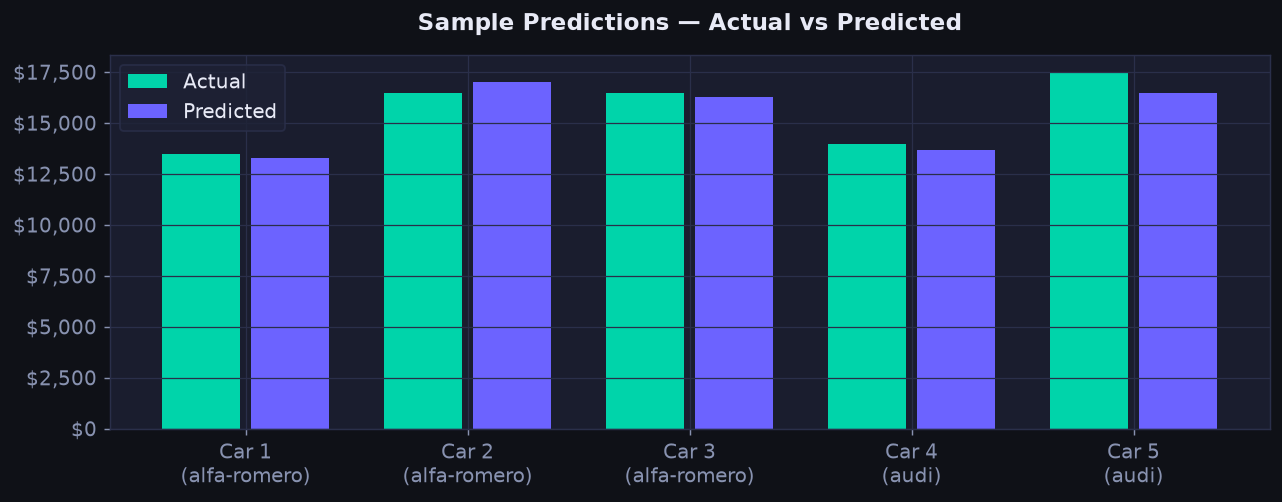

In [ ]:
# ── 9.3 Sample Predictions ────────────────────────────────────────────────────
sample       = X_test.head(5).copy()
sample_prep  = preprocessor.transform(sample)
sample_preds = final_model.predict(sample_prep)

comparison = sample.copy()
comparison['Actual Price ($)']    = y_test.head(5).values
comparison['Predicted Price ($)'] = sample_preds.round(2)
comparison['Error ($)']           = (comparison['Actual Price ($)'] -
                                      comparison['Predicted Price ($)']).round(2)
comparison['Abs Error (%)']       = (abs(comparison['Error ($)']) /
                                      comparison['Actual Price ($)'] * 100).round(1)

out = comparison[['make','engine-size','horsepower','curb-weight',
                   'Actual Price ($)','Predicted Price ($)','Error ($)','Abs Error (%)']]
display(out)

# ── Sample prediction bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

x_pos  = np.arange(5)
labels = [f"Car {i+1}\n({row['make']})" for i, (_, row) in enumerate(out.iterrows())]
ax.bar(x_pos - 0.2, comparison['Actual Price ($)'],    0.35, label='Actual',    color=GREEN,  edgecolor='none')
ax.bar(x_pos + 0.2, comparison['Predicted Price ($)'], 0.35, label='Predicted', color=PURPLE, edgecolor='none')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_title('Sample Predictions — Actual vs Predicted', pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 9.4 Styled summary metrics dashboard ──────────────────────────────────────
final_r2   = max(tuned_r2, orig_r2)
final_mae  = tuned_mae  if tuned_r2 >= orig_r2 else mean_absolute_error(y_test, y_pred_best)
final_rmse = tuned_rmse if tuned_r2 >= orig_r2 else np.sqrt(mean_squared_error(y_test, y_pred_best))
final_mape = tuned_mape if tuned_r2 >= orig_r2 else mean_absolute_percentage_error(y_test, y_pred_best)*100

display(HTML(f"""
<div style="
    background: linear-gradient(135deg, #1a1d2e 0%, #12162a 100%);
    border: 1px solid #2a2f4a;
    border-radius: 14px;
    padding: 28px 32px;
    font-family: 'Segoe UI', system-ui, sans-serif;
    margin-top: 20px;
">
  <div style="font-size:1.1em; font-weight:700; color:#e8eaf6; margin-bottom:20px;"
  >🏆 Final Model: {final_model_name}</div>
  <div style="display:flex; gap:16px; flex-wrap:wrap;">
    <div style="background:#0f1117; border:1px solid #2a2f4a; border-left:4px solid #00d4aa;
                border-radius:10px; padding:16px 22px; min-width:130px;">
      <div style="font-size:0.72em; color:#8892b0; text-transform:uppercase; letter-spacing:1px;">Test R²</div>
      <div style="font-size:1.8em; font-weight:800; color:#00d4aa;">{final_r2:.4f}</div>
    </div>
    <div style="background:#0f1117; border:1px solid #2a2f4a; border-left:4px solid #ffd166;
                border-radius:10px; padding:16px 22px; min-width:130px;">
      <div style="font-size:0.72em; color:#8892b0; text-transform:uppercase; letter-spacing:1px;">Test MAE</div>
      <div style="font-size:1.8em; font-weight:800; color:#ffd166;">${final_mae:,.0f}</div>
    </div>
    <div style="background:#0f1117; border:1px solid #2a2f4a; border-left:4px solid #ff6584;
                border-radius:10px; padding:16px 22px; min-width:130px;">
      <div style="font-size:0.72em; color:#8892b0; text-transform:uppercase; letter-spacing:1px;">Test RMSE</div>
      <div style="font-size:1.8em; font-weight:800; color:#ff6584;">${final_rmse:,.0f}</div>
    </div>
    <div style="background:#0f1117; border:1px solid #2a2f4a; border-left:4px solid #6c63ff;
                border-radius:10px; padding:16px 22px; min-width:130px;">
      <div style="font-size:0.72em; color:#8892b0; text-transform:uppercase; letter-spacing:1px;">Test MAPE</div>
      <div style="font-size:1.8em; font-weight:800; color:#6c63ff;">{final_mape:.1f}%</div>
    </div>
  </div>
</div>
"""))

In [ ]:
section_banner('10. Interactive Frontend (ipywidgets)',
               'Configure any car spec below and get a live price prediction', GREEN)

In [ ]:
# ── Helper ────────────────────────────────────────────────────────────────────
def uniq(col): return sorted(df[col].dropna().unique().tolist())

# ── Widget styles ─────────────────────────────────────────────────────────────
S = {'description_width': '160px'}
L = widgets.Layout(width='380px')
L_slider = widgets.Layout(width='380px')

# ── Dropdowns ────────────────────────────────────────────────────────────────
w_make        = widgets.Dropdown(options=uniq('make'),            description='Make',             style=S, layout=L)
w_fuel        = widgets.Dropdown(options=uniq('fuel-type'),       description='Fuel Type',         style=S, layout=L)
w_aspiration  = widgets.Dropdown(options=uniq('aspiration'),      description='Aspiration',        style=S, layout=L)
w_doors       = widgets.Dropdown(options=uniq('num-of-doors'),    description='Num of Doors',      style=S, layout=L)
w_body        = widgets.Dropdown(options=uniq('body-style'),      description='Body Style',        style=S, layout=L)
w_drive       = widgets.Dropdown(options=uniq('drive-wheels'),    description='Drive Wheels',      style=S, layout=L)
w_engine_loc  = widgets.Dropdown(options=uniq('engine-location'), description='Engine Location',   style=S, layout=L)
w_engine_type = widgets.Dropdown(options=uniq('engine-type'),     description='Engine Type',       style=S, layout=L)
w_cylinders   = widgets.Dropdown(options=uniq('num-of-cylinders'),description='Num of Cylinders',  style=S, layout=L)
w_fuel_sys    = widgets.Dropdown(options=uniq('fuel-system'),     description='Fuel System',       style=S, layout=L)

# ── Sliders / inputs ─────────────────────────────────────────────────────────
w_symboling  = widgets.IntSlider(  value=0,    min=-3,   max=3,    step=1,    description='Symboling',          style=S, layout=L_slider)
w_norm_loss  = widgets.FloatText(  value=122,                                  description='Normalized Losses',  style=S, layout=L)
w_wheelbase  = widgets.FloatSlider(value=98.0, min=86.0, max=121.0,step=0.1,  description='Wheel Base (in)',    style=S, layout=L_slider)
w_length     = widgets.FloatSlider(value=174.0,min=141.0,max=209.0,step=0.1,  description='Length (in)',        style=S, layout=L_slider)
w_width      = widgets.FloatSlider(value=65.0, min=60.0, max=73.0, step=0.1,  description='Width (in)',         style=S, layout=L_slider)
w_height     = widgets.FloatSlider(value=54.0, min=47.0, max=60.0, step=0.1,  description='Height (in)',        style=S, layout=L_slider)
w_curb_wt    = widgets.IntSlider(  value=2500, min=1488, max=4066, step=10,   description='Curb Weight (lb)',   style=S, layout=L_slider)
w_eng_size   = widgets.IntSlider(  value=120,  min=61,   max=326,  step=1,    description='Engine Size (cc)',   style=S, layout=L_slider)
w_bore       = widgets.FloatSlider(value=3.3,  min=2.5,  max=3.9,  step=0.01, description='Bore (in)',          style=S, layout=L_slider)
w_stroke     = widgets.FloatSlider(value=3.4,  min=2.0,  max=4.2,  step=0.01, description='Stroke (in)',        style=S, layout=L_slider)
w_comp_ratio = widgets.FloatSlider(value=9.0,  min=7.0,  max=23.0, step=0.1,  description='Compression Ratio',  style=S, layout=L_slider)
w_hp         = widgets.IntSlider(  value=100,  min=48,   max=288,  step=1,    description='Horsepower',         style=S, layout=L_slider)
w_peak_rpm   = widgets.IntSlider(  value=5000, min=4150, max=6600, step=50,   description='Peak RPM',           style=S, layout=L_slider)
w_city_mpg   = widgets.IntSlider(  value=25,   min=13,   max=49,   step=1,    description='City MPG',           style=S, layout=L_slider)
w_hwy_mpg    = widgets.IntSlider(  value=30,   min=16,   max=54,   step=1,    description='Highway MPG',        style=S, layout=L_slider)

btn_predict = widgets.Button(
    description='🔮  Predict Price',
    button_style='success',
    layout=widgets.Layout(width='220px', height='44px')
)
btn_clear = widgets.Button(
    description='🗑  Clear',
    button_style='warning',
    layout=widgets.Layout(width='120px', height='44px')
)
out_result = widgets.Output()

print('Widgets initialised ✅')

In [ ]:
# ── Prediction callback ────────────────────────────────────────────────────────
def on_predict(b):
    with out_result:
        out_result.clear_output(wait=True)

        input_dict = {
            'symboling'         : [w_symboling.value],
            'normalized-losses' : [w_norm_loss.value],
            'make'              : [w_make.value],
            'fuel-type'         : [w_fuel.value],
            'aspiration'        : [w_aspiration.value],
            'num-of-doors'      : [w_doors.value],
            'body-style'        : [w_body.value],
            'drive-wheels'      : [w_drive.value],
            'engine-location'   : [w_engine_loc.value],
            'wheel-base'        : [w_wheelbase.value],
            'length'            : [w_length.value],
            'width'             : [w_width.value],
            'height'            : [w_height.value],
            'curb-weight'       : [w_curb_wt.value],
            'engine-type'       : [w_engine_type.value],
            'num-of-cylinders'  : [w_cylinders.value],
            'engine-size'       : [w_eng_size.value],
            'fuel-system'       : [w_fuel_sys.value],
            'bore'              : [w_bore.value],
            'stroke'            : [w_stroke.value],
            'compression-ratio' : [w_comp_ratio.value],
            'horsepower'        : [w_hp.value],
            'peak-rpm'          : [w_peak_rpm.value],
            'city-mpg'          : [w_city_mpg.value],
            'highway-mpg'       : [w_hwy_mpg.value]
        }

        input_df = pd.DataFrame(input_dict)
        for col in numerical_cols:
            input_df[col] = pd.to_numeric(input_df[col], errors='coerce')

        input_prep = preprocessor.transform(input_df)
        pred_price = final_model.predict(input_prep)[0]
        low_est    = pred_price * 0.92
        high_est   = pred_price * 1.08

        display(HTML(f"""
        <div style="
            background: linear-gradient(135deg, #1a1d2e 0%, #12162a 100%);
            border: 1px solid #2a2f4a;
            border-left: 5px solid #00d4aa;
            border-radius: 12px;
            padding: 24px 32px;
            font-family: 'Segoe UI', system-ui, sans-serif;
            max-width: 480px;
            margin-top: 10px;
        ">
          <div style="font-size:0.72em; color:#8892b0; text-transform:uppercase;
                      letter-spacing:1.2px; margin-bottom:6px;">Estimated Market Price</div>
          <div style="font-size:2.6em; font-weight:800; color:#00d4aa; letter-spacing:-1px;">
            ${pred_price:,.2f}
          </div>
          <div style="display:flex; gap:12px; margin-top:14px;">
            <span style="background:#0f1117; border:1px solid #2a2f4a; border-radius:20px;
                         padding:4px 14px; font-size:0.78em; color:#8892b0;">
              Low: ${low_est:,.0f}
            </span>
            <span style="background:#0f1117; border:1px solid #2a2f4a; border-radius:20px;
                         padding:4px 14px; font-size:0.78em; color:#8892b0;">
              High: ${high_est:,.0f}
            </span>
          </div>
          <div style="font-size:0.78em; color:#8892b0; margin-top:12px;">
            Model: <b style='color:#6c63ff;'>{final_model_name}</b>
            &nbsp;·&nbsp; Test R² = <b style='color:#00d4aa;'>{max(tuned_r2, orig_r2):.4f}</b>
          </div>
        </div>
        """))

        # ── Mini bar chart: user input vs dataset averages ─────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
        fig.patch.set_facecolor('#0f1117')
        fig.suptitle(f'Your Car Specs vs Dataset Average — Predicted: ${pred_price:,.0f}',
                     color='#e8eaf6', fontsize=12, fontweight='bold')

        metrics = [
            ('Engine Size', w_eng_size.value,  df['engine-size'].median(),  'cc'),
            ('Horsepower',  w_hp.value,        df['horsepower'].median(),   'hp'),
            ('Curb Weight', w_curb_wt.value,   df['curb-weight'].median(),  'lb'),
        ]
        for ax, (label, user_val, avg_val, unit) in zip(axes, metrics):
            ax.set_facecolor('#1a1d2e')
            ax.bar(['You', 'Dataset\nAvg'], [user_val, avg_val],
                   color=[PURPLE, GREEN], edgecolor='none', width=0.5)
            ax.set_title(f'{label} ({unit})')
            ax.set_ylabel(unit)
        plt.tight_layout()
        plt.show()

def on_clear(b):
    with out_result:
        out_result.clear_output()

btn_predict.on_click(on_predict)
btn_clear.on_click(on_clear)

In [ ]:
# ── Layout and Display ─────────────────────────────────────────────────────────
display(HTML("""
<div style="
    background: linear-gradient(135deg, #1a1d2e 0%, #12162a 100%);
    border: 1px solid #2a2f4a;
    border-radius: 14px;
    padding: 22px 28px 10px 28px;
    font-family: 'Segoe UI', system-ui, sans-serif;
    margin-bottom: 12px;
">
  <div style='font-size:1.4em; font-weight:700; color:#e8eaf6;'>🚗 Car Price Predictor</div>
  <div style='font-size:0.85em; color:#8892b0; margin-top:4px;'>
    Adjust the car specifications below and click <b style='color:#6c63ff;'>Predict Price</b>.
    A comparison chart of your specs vs dataset averages will appear below the result.
  </div>
</div>
"""))

col1 = widgets.VBox([
    widgets.HTML('<div style="font-size:0.8em;font-weight:600;color:#8892b0;text-transform:uppercase;letter-spacing:1px;padding-bottom:6px;border-bottom:1px solid #2a2f4a;margin-bottom:8px;">🚘 Car Identity</div>'),
    w_make, w_fuel, w_aspiration, w_doors, w_body, w_drive,
    w_engine_loc, w_symboling, w_norm_loss
])

col2 = widgets.VBox([
    widgets.HTML('<div style="font-size:0.8em;font-weight:600;color:#8892b0;text-transform:uppercase;letter-spacing:1px;padding-bottom:6px;border-bottom:1px solid #2a2f4a;margin-bottom:8px;">📐 Dimensions & Weight</div>'),
    w_wheelbase, w_length, w_width, w_height, w_curb_wt
])

col3 = widgets.VBox([
    widgets.HTML('<div style="font-size:0.8em;font-weight:600;color:#8892b0;text-transform:uppercase;letter-spacing:1px;padding-bottom:6px;border-bottom:1px solid #2a2f4a;margin-bottom:8px;">⚙️ Engine & Performance</div>'),
    w_engine_type, w_cylinders, w_fuel_sys,
    w_eng_size, w_bore, w_stroke,
    w_comp_ratio, w_hp, w_peak_rpm,
    w_city_mpg, w_hwy_mpg
])

form = widgets.HBox([col1, col2, col3],
                    layout=widgets.Layout(gap='24px'))

display(form)
display(widgets.HBox([btn_predict, btn_clear],
                     layout=widgets.Layout(margin='16px 0 0 0', gap='10px')))
display(out_result)

---
## Summary

| Step | Details |
|------|----------|
| Dataset | 199 cars × 26 features (UCI Automobile Dataset) |
| Target | `price` (continuous, USD) |
| Missing Values | Replaced `?` with NaN; imputed with median/mode |
| Preprocessing | `StandardScaler` + `OneHotEncoder` via `ColumnTransformer` |
| Models Tested | 10 algorithms (Linear Regression → Gradient Boosting) |
| Best Model | Tuned **Random Forest** |
| Evaluation | 5-fold CV R², Test R², MAE, RMSE, MAPE |
| Frontend | Interactive `ipywidgets` form with live prediction + inline charts |
| Saved Artefacts | `car_price_model.pkl`, `car_price_preprocessor.pkl` |